# Master's Thesis in Advanced Physics
---

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026

# Difussion Run 2: Generative Diffusion Model for CORSIKA Neutrino Cubes

This notebook trains a conditional denoising diffusion model to generate neutrino-flux cubes with the same tensor structure used by the diffusion-ready CORSIKA dataset built in `run6_Corsika_BuildDataset.ipynb`.

The expected HDF5 input is `neutrino_diffusion_cubes.h5` or an equivalent file with sample tensors under `samples/`. The canonical target is `samples/log10_differential_flux` with axis order `(sample, channel/flavor, height, theta, energy)`, plus `samples/condition`, `samples/valid_mask`, raw counts, uncertainty estimates, and grid metadata.


## 1. Libraries

This section imports the scientific Python and PyTorch stack, enables inline plotting, and reports CUDA, device, and VRAM diagnostics before any training code is built.


In [ ]:
from __future__ import annotations
%matplotlib inline

from dataclasses import dataclass, fields
from pathlib import Path
from typing import Any
import atexit
import math
import os
import random
import time

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset, random_split

from tpeanuts.notebooks.notebookConfig import load_notebook_config

config = load_notebook_config()


In [2]:
# Section 1 diagnostic: verify core versions, CUDA availability, and GPU/VRAM resources.
print(f"Python scientific stack: numpy={np.__version__}, pandas={pd.__version__}, h5py={h5py.__version__}")
print(f"CPU Cores: {os.cpu_count()}")
print(f"Torch version: {torch.__version__}")
print(f"Torch built with CUDA: {torch.version.cuda}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA device count: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    for idx in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(idx)
        total_gb = props.total_memory / 1024**3
        allocated_gb = torch.cuda.memory_allocated(idx) / 1024**3
        reserved_gb = torch.cuda.memory_reserved(idx) / 1024**3
        free_gb = total_gb - reserved_gb
        print(
            f"cuda:{idx} | {props.name} | capability={props.major}.{props.minor} | "
            f"total={total_gb:.2f} GB | reserved={reserved_gb:.2f} GB | "
            f"allocated={allocated_gb:.2f} GB | approx_free={free_gb:.2f} GB"
        )
else:
    print("No CUDA device is visible to PyTorch; the notebook will use CPU unless this changes.")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Selected device: {DEVICE}")
assert torch.__version__


Python scientific stack: numpy=1.26.4, pandas=2.3.3, h5py=3.14.0
CPU Cores: 16
Torch version: 2.3.1
Torch built with CUDA: 12.1
CUDA available: True
CUDA device count: 1
cuda:0 | NVIDIA GeForce GTX 1080 Ti | capability=6.1 | total=11.00 GB | reserved=0.00 GB | allocated=0.00 GB | approx_free=11.00 GB
Selected device: cuda


## 2. Model and Simulation Parameters

This section defines the reproducibility settings, diffusion hyperparameters, dataloader controls, model size, and generation settings. Paths are kept in an independent block so the dataset, checkpoint, and output locations can be changed without touching training logic.


### 2.1. Paths

The default path follows the Run 4 dataset location. Adjust `PATH_DATASET_MODEL` if your Run 6 notebook writes the HDF5 file somewhere else.


In [ ]:
RUN = "run_2"

OUTPUT_ROOT = config.output_root
OUTPUT_DATA_ROOT = config.output_data_root
OUTPUT_CORSIKA_ROOT = Path(OUTPUT_DATA_ROOT / "corsika")
OUTPUT_DIFUSSION_ROOT = Path(OUTPUT_DATA_ROOT / "difussion")
OUTPUT_CORSIKA_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_DIFUSSION_ROOT.mkdir(parents=True, exist_ok=True)

PATH_OUTPUT_CORSIKA_GENERATOR = Path(OUTPUT_CORSIKA_ROOT / "generator")
PATH_OUTPUT_RUN = Path(PATH_OUTPUT_CORSIKA_GENERATOR / RUN)
PATH_MANIFEST_FILE = Path(PATH_OUTPUT_RUN / "manifest.csv")

PATH_OUTPUT_DATASET = Path(OUTPUT_DIFUSSION_ROOT / "dataset")
PATH_OUTPUT_DATASET_RUN = PATH_OUTPUT_DATASET / RUN
PATH_OUTPUT_DATASET_RUN.mkdir(parents=True, exist_ok=True)

PATH_DATASET_NEUTRINO_PARTICLES_NPZ = PATH_OUTPUT_DATASET_RUN / "dataset_neutrino_particles.npz"
PATH_DATASET_NEUTRINO_PARTICLES_PARQUET = PATH_OUTPUT_DATASET_RUN / "dataset_neutrino_particles.parquet"
PATH_DATASET_NEUTRINO_CUBES = PATH_OUTPUT_DATASET_RUN / "dataset_neutrino_cubes.h5"
PATH_DATASET_NEUTRINO_METADATA = PATH_OUTPUT_DATASET_RUN / "dataset_neutrino_metadata.json"

PATH_OUTPUT_MODEL = Path(OUTPUT_DIFUSSION_ROOT / "model")
PATH_OUTPUT_MODEL_RUN = Path(PATH_OUTPUT_MODEL / RUN)
PATH_DIFUSSION_MODEL = PATH_OUTPUT_MODEL_RUN / "model_difussion_neutrino_cube3D.h5"
PATH_MODEL_CHECKPOINTS = PATH_OUTPUT_MODEL_RUN / "checkpoints"
PATH_LAST_MODEL = PATH_MODEL_CHECKPOINTS / "model_last_epoch.pt"
PATH_BEST_MODEL = PATH_MODEL_CHECKPOINTS / "model_best_epoch.pt"
PATH_MODEL_GENERATED = PATH_OUTPUT_MODEL_RUN / "generated"

print(" Configured workflow paths:\n", "=" * 80)
print(" - OUTPUT_ROOT = ", OUTPUT_ROOT)
print(" - OUTPUT_DATA_ROOT = ", OUTPUT_DATA_ROOT)
print(" - OUTPUT_CORSIKA_ROOT = ", OUTPUT_CORSIKA_ROOT)
print(" - OUTPUT_DIFUSSION_ROOT = ", OUTPUT_DIFUSSION_ROOT)
print(" - RUN = ", RUN, "\n")
print(" - PATH_MANIFEST_FILE = ", PATH_MANIFEST_FILE)

print(" Output paths:\n", "=" * 80)
print(" - PATH_OUTPUT_DATASET_RUN                  = ", PATH_OUTPUT_DATASET_RUN)
print(" - PATH_DATASET_NEUTRINO_PARTICLES_NPZ      = ", PATH_DATASET_NEUTRINO_PARTICLES_NPZ)
print(" - PATH_DATASET_NEUTRINO_PARTICLES_PARQUET  = ", PATH_DATASET_NEUTRINO_PARTICLES_PARQUET)
print(" - PATH_DATASET_NEUTRINO_CUBES              = ", PATH_DATASET_NEUTRINO_CUBES)
print(" - PATH_DATASET_NEUTRINO_METADATA           = ", PATH_DATASET_NEUTRINO_METADATA)

print(" - PATH_OUTPUT_MODEL                  = ", PATH_OUTPUT_MODEL)
print(" - PATH_DIFUSSION_MODEL               = ", PATH_DIFUSSION_MODEL)
print(" - PATH_MODEL_CHECKPOINTS             = ", PATH_MODEL_CHECKPOINTS)
print(" - PATH_MODEL_GENERATED               = ", PATH_MODEL_GENERATED)
print(" - PATH_BEST_MODEL                    = ", PATH_BEST_MODEL)
for directory in [PATH_OUTPUT_MODEL, PATH_OUTPUT_MODEL_RUN, PATH_MODEL_CHECKPOINTS, PATH_MODEL_GENERATED]:
    directory.mkdir(parents=True, exist_ok=True)

### 2.2. Parameters and Configuration

In [4]:
# ==========================================================
# Dataset
# ==========================================================

CUBE_TARGET = "log10_differential_flux_valid"
USE_VALID_MASK_LOSS = True
MIN_VALID_LOSS_WEIGHT = 0.0
LOSS_WEIGHT_SOURCE = "raw_counts"  # "none", "relative_uncertainty", or "raw_counts"
LOSS_WEIGHT_EPSILON = 1e-3
LOSS_WEIGHT_CLIP = 10.0

SEED = 42

TRAIN_FRACTION = 0.80
VAL_FRACTION = 0.10
TEST_FRACTION = 0.10

BATCH_SIZE = 4
NUM_WORKERS = 0  
DATALOADER_PREFETCH_FACTOR = 2
DATALOADER_PERSISTENT_WORKERS = True

# HDF5 access mode options:
# - "per_getitem": current behavior, opens the HDF5 file for each sample.
# - "worker_handle": opens one HDF5 handle per DataLoader worker.
# - "preload_ram": loads training tensors into RAM at dataset construction time.
H5_ACCESS_MODE = "preload_ram"

# ==========================================================
# Training
# ==========================================================

EPOCHS = 50

LEARNING_RATE = 2e-4
WEIGHT_DECAY = 1e-4

GRAD_CLIP_NORM = 1.0

USE_AMP = False

# ==========================================================
# Diffusion process
# ==========================================================

DIFFUSION_STEPS = 300

BETA_START = 1e-4
BETA_END = 2e-2
BETA_SCHEDULE = "cosine"  # "cosine",  "linear" .
PREDICTION_TARGET = "v"   # "epsilon", "v", or "x0".
MIN_SNR_GAMMA = 5.0       # None to disable Min-SNR loss reweighting.

# ==========================================================
# Model
# ==========================================================

BASE_CHANNELS = 32
TIME_DIM = 128
CONDITION_DIM = 128
NORMALIZE_CONDITION = True
CONDITION_EXCLUDE_COLUMNS = ["event_id_start", "event_id_end"]
USE_SUPPORT_HEAD = True
SUPPORT_LOSS_WEIGHT = 0.25
SUPPORT_POS_WEIGHT = None

EMA_DECAY = 0.995

# ==========================================================
# Scheduler
# ==========================================================

SCHEDULER_PATIENCE = 6
SCHEDULER_FACTOR = 0.8

# ==========================================================
# Numerical stability
# ==========================================================

NORM_EPSILON = 1e-6

# ==========================================================
# Sampling
# ==========================================================

SAMPLE_COUNT = 4
SAMPLE_METHOD = "ddim"  # "ddim" is faster for generation; use "ddpm" for the original sampler.
SAMPLE_STEPS = 50       # Only used by DDIM; keep <= DIFFUSION_STEPS.

@dataclass(frozen=True)
class DiffusionConfig:
    """Configuration for conditional diffusion training on CORSIKA neutrino cubes."""

    dataset_path: Path = Path(PATH_DATASET_NEUTRINO_CUBES)
    checkpoint_dir: Path = Path(PATH_MODEL_CHECKPOINTS)
    generated_dir: Path = Path(PATH_MODEL_GENERATED)
    model_file: Path = Path(PATH_DIFUSSION_MODEL )
    model_last_epoch: Path = Path(PATH_LAST_MODEL )
    model_best_epoch: Path = Path(PATH_BEST_MODEL )
    cube_target: str = "log10_differential_flux_valid"
    use_valid_mask_loss: bool = True
    min_valid_loss_weight: float = 0.0
    loss_weight_source: str = "raw_counts"
    loss_weight_epsilon: float = 1e-3
    loss_weight_clip: float = 10.0
    seed: int = 42
    train_fraction: float = 0.80
    val_fraction: float = 0.10
    test_fraction: float = 0.10
    batch_size: int = 4
    num_workers: int = 4
    dataloader_prefetch_factor: int = 2
    dataloader_persistent_workers: bool = True
    h5_access_mode: str = "worker_handle"
    epochs: int = 50
    learning_rate: float = 2e-4
    weight_decay: float = 1e-4
    grad_clip_norm: float = 1.0
    diffusion_steps: int = 300
    beta_start: float = 1e-4
    beta_end: float = 2e-2
    beta_schedule: str = "cosine"
    prediction_target: str = "v"
    min_snr_gamma: float | None = 5.0
    base_channels: int = 32
    time_dim: int = 128
    condition_dim: int = 128
    normalize_condition: bool = True
    condition_exclude_columns: list[str] | None = None
    use_support_head: bool = True
    support_loss_weight: float = 0.25
    support_pos_weight: float | None = None
    ema_decay: float = 0.995
    use_amp: bool = False
    scheduler_patience: int = 4
    scheduler_factor: float = 0.5
    norm_epsilon: float = 1e-6
    sample_count: int = 4
    sample_method: str = "ddim"
    sample_steps: int = 50


CONFIG = DiffusionConfig(
    dataset_path=Path(PATH_DATASET_NEUTRINO_CUBES),
    checkpoint_dir=Path(PATH_MODEL_CHECKPOINTS),
    generated_dir=Path(PATH_MODEL_GENERATED),
    model_file = Path(PATH_DIFUSSION_MODEL ),
    model_last_epoch = Path(PATH_LAST_MODEL ),
    model_best_epoch = Path(PATH_BEST_MODEL ),
    cube_target=CUBE_TARGET,
    use_valid_mask_loss=USE_VALID_MASK_LOSS,
    min_valid_loss_weight=MIN_VALID_LOSS_WEIGHT,
    loss_weight_source=LOSS_WEIGHT_SOURCE,
    loss_weight_epsilon=LOSS_WEIGHT_EPSILON,
    loss_weight_clip=LOSS_WEIGHT_CLIP,
    seed=SEED,
    train_fraction=TRAIN_FRACTION,
    val_fraction=VAL_FRACTION,
    test_fraction=TEST_FRACTION,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    dataloader_prefetch_factor=DATALOADER_PREFETCH_FACTOR,
    dataloader_persistent_workers=DATALOADER_PERSISTENT_WORKERS,
    h5_access_mode=H5_ACCESS_MODE,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    grad_clip_norm=GRAD_CLIP_NORM,
    diffusion_steps=DIFFUSION_STEPS,
    beta_start=BETA_START,
    beta_end=BETA_END,
    beta_schedule=BETA_SCHEDULE,
    prediction_target=PREDICTION_TARGET,
    min_snr_gamma=MIN_SNR_GAMMA,
    base_channels=BASE_CHANNELS,
    time_dim=TIME_DIM,
    condition_dim=CONDITION_DIM,
    normalize_condition=NORMALIZE_CONDITION,
    condition_exclude_columns=CONDITION_EXCLUDE_COLUMNS,
    use_support_head=USE_SUPPORT_HEAD,
    support_loss_weight=SUPPORT_LOSS_WEIGHT,
    support_pos_weight=SUPPORT_POS_WEIGHT,
    ema_decay=EMA_DECAY,
    use_amp=USE_AMP,
    scheduler_patience=SCHEDULER_PATIENCE,
    scheduler_factor=SCHEDULER_FACTOR,
    norm_epsilon=NORM_EPSILON,
    sample_count=SAMPLE_COUNT,
    sample_method=SAMPLE_METHOD,
    sample_steps=SAMPLE_STEPS,
)
CONFIG.checkpoint_dir.mkdir(parents=True, exist_ok=True)
CONFIG.generated_dir.mkdir(parents=True, exist_ok=True)
print("\n" + "=" * 80)
print(f"{'PARAMETER':<35} {'VALUE'}")
print("=" * 80)

for field in fields(CONFIG):
    value = getattr(CONFIG, field.name)
    print(f"{field.name:<35} {value}")

print("=" * 80)



PARAMETER                           VALUE
dataset_path                        V:\output\data\difussion\dataset\run_2\dataset_neutrino_cubes.h5
checkpoint_dir                      V:\output\data\difussion\model\run_2\checkpoints
generated_dir                       V:\output\data\difussion\model\run_2\generated
model_file                          V:\output\data\difussion\model\run_2\model_difussion_neutrino_cube3D.h5
model_last_epoch                    V:\output\data\difussion\model\run_2\checkpoints\model_last_epoch.pt
model_best_epoch                    V:\output\data\difussion\model\run_2\checkpoints\model_best_epoch.pt
cube_target                         log10_differential_flux_valid
use_valid_mask_loss                 True
min_valid_loss_weight               0.0
loss_weight_source                  raw_counts
loss_weight_epsilon                 0.001
loss_weight_clip                    10.0
seed                                42
train_fraction                      0.8
val_fraction  

In [5]:
# Section 2 diagnostic: reproducibility and parameter checks.
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(CONFIG.seed)
assert math.isclose(CONFIG.train_fraction + CONFIG.val_fraction + CONFIG.test_fraction, 1.0)
assert CONFIG.diffusion_steps > 1
assert CONFIG.beta_start < CONFIG.beta_end
print(f"Seed fixed to {CONFIG.seed}")
print(f"Diffusion cube dataset path exists: {CONFIG.dataset_path.exists()} -> {CONFIG.dataset_path}")


Seed fixed to 42
Diffusion cube dataset path exists: True -> V:\output\data\difussion\dataset\run_2\dataset_neutrino_cubes.h5


## 3. Dataset Creation

This section defines a PyTorch dataset equivalent to the `NeutrinoCubeH5Dataset` from Run 6. It reads the diffusion-ready HDF5 cube file directly, using `samples/log10_differential_flux` as the training target and returning the conditioning vector, valid mask, raw counts, relative uncertainty, and sample index.

The target tensor has shape `(channel/flavor, height, theta, energy)`, which is already compatible with 3D convolutions as `(channels, depth, height, width)`.


In [6]:
def decode_h5_strings(values: np.ndarray) -> list[str]:
    return [x.decode("utf-8") if isinstance(x, bytes) else str(x) for x in values]


def compute_h5_mean_std(path: Path, dataset_key: str, norm_epsilon: float, chunk_size: int = 16) -> tuple[float, float]:
    """Compute finite mean/std for an HDF5 sample tensor without loading all samples at once."""
    count = 0
    total = 0.0
    total_sq = 0.0
    with h5py.File(path, "r") as h5:
        data = h5[dataset_key]
        for start in range(0, data.shape[0], chunk_size):
            arr = np.asarray(data[start:start + chunk_size], dtype=np.float64)
            arr = np.nan_to_num(arr, nan=-300.0, neginf=-300.0, posinf=0.0)
            finite = arr[np.isfinite(arr)]
            count += finite.size
            total += float(finite.sum())
            total_sq += float(np.square(finite).sum())
    if count == 0:
        return 0.0, 1.0
    mean = total / count
    var = max(total_sq / count - mean * mean, 0.0)
    return float(mean), float(math.sqrt(var) + norm_epsilon)


class NeutrinoCubeH5Dataset(Dataset):
    """PyTorch Dataset for block-sampled CORSIKA neutrino diffusion cubes."""

    VALID_H5_ACCESS_MODES = {"per_getitem", "worker_handle", "preload_ram"}
    VALID_LOSS_WEIGHT_SOURCES = {"none", "relative_uncertainty", "raw_counts"}

    def __init__(
        self,
        path: str | Path,
        target: str = "log10_differential_flux",
        norm_epsilon: float = 1e-6,
        h5_access_mode: str = "per_getitem",
        normalize_condition: bool = True,
        loss_weight_source: str = "none",
        loss_weight_epsilon: float = 1e-3,
        loss_weight_clip: float = 10.0,
        condition_exclude_columns: list[str] | None = None,
    ):
        self.path = Path(path)
        self.target = target
        self.target_key = f"samples/{target}"
        self.requested_target_key = self.target_key
        self.norm_epsilon = float(norm_epsilon)
        self.h5_access_mode = str(h5_access_mode)
        self.normalize_condition = bool(normalize_condition)
        self.loss_weight_source = str(loss_weight_source)
        self.loss_weight_epsilon = float(loss_weight_epsilon)
        self.loss_weight_clip = float(loss_weight_clip)
        self.condition_exclude_columns = set(condition_exclude_columns or [])
        self.condition_keep_indices: np.ndarray | None = None
        if self.h5_access_mode not in self.VALID_H5_ACCESS_MODES:
            raise ValueError(f"h5_access_mode must be one of {sorted(self.VALID_H5_ACCESS_MODES)}, got {self.h5_access_mode!r}")
        if self.loss_weight_source not in self.VALID_LOSS_WEIGHT_SOURCES:
            raise ValueError(f"loss_weight_source must be one of {sorted(self.VALID_LOSS_WEIGHT_SOURCES)}, got {self.loss_weight_source!r}")
        if not self.path.exists():
            raise FileNotFoundError(f"Diffusion cube HDF5 not found: {self.path}")

        self._h5: h5py.File | None = None
        self._preloaded: dict[str, np.ndarray] | None = None
        self.condition_mean: np.ndarray | None = None
        self.condition_std: np.ndarray | None = None

        with h5py.File(self.path, "r") as h5:
            if self.target_key not in h5:
                fallback_key = "samples/log10_differential_flux"
                available = sorted(h5.get("samples", {}).keys()) if "samples" in h5 else []
                if fallback_key in h5:
                    print(f"Requested target '{self.target_key}' not found. Falling back to '{fallback_key}'.")
                    self.target = "log10_differential_flux"
                    self.target_key = fallback_key
                else:
                    raise KeyError(f"Missing '{self.target_key}'. Available sample datasets: {available}")
            self.n_samples = int(h5[self.target_key].shape[0])
            self.sample_shape = tuple(int(x) for x in h5[self.target_key].shape[1:])
            self.has_condition = "samples/condition" in h5
            self.has_valid_mask = "samples/valid_mask" in h5
            self.has_support_mask = "samples/support_mask" in h5
            self.has_raw_counts = "samples/raw_counts" in h5
            self.has_relative_uncertainty = "samples/relative_uncertainty" in h5
            all_condition_columns = decode_h5_strings(h5["samples/condition_columns"][:]) if "samples/condition_columns" in h5 else []
            self.condition_keep_indices = np.asarray([i for i, col in enumerate(all_condition_columns) if col not in self.condition_exclude_columns], dtype=np.int64)
            self.condition_columns = [all_condition_columns[i] for i in self.condition_keep_indices] if all_condition_columns else []
            self.condition_dim = len(self.condition_columns) if self.has_condition else 0
            self.flavor_order = decode_h5_strings(h5["grid/flavor_order"][:]) if "grid/flavor_order" in h5 else []
            self.energy_centers = np.asarray(h5["grid/energy_centers_gev"], dtype=np.float32)
            self.theta_centers = np.asarray(h5["grid/theta_centers_deg"], dtype=np.float32)
            self.h_centers = np.asarray(h5["grid/h_centers_m"], dtype=np.float32)
            self.attrs = dict(h5.attrs)

        if self.n_samples <= 0:
            raise ValueError(f"No samples found in {self.target_key}")
        if len(self.sample_shape) != 4:
            raise ValueError(f"Expected sample shape (channel, height, theta, energy), got {self.sample_shape}")

        self.mean, self.std = compute_h5_mean_std(self.path, self.target_key, self.norm_epsilon)
        self.set_condition_normalization()
        if self.h5_access_mode == "preload_ram":
            self._preload_training_arrays()

    def __len__(self) -> int:
        return self.n_samples

    def __getstate__(self) -> dict[str, Any]:
        state = self.__dict__.copy()
        state["_h5"] = None
        return state

    def __del__(self) -> None:
        self.close()

    def close(self) -> None:
        if self._h5 is not None:
            self._h5.close()
            self._h5 = None

    def _get_h5(self) -> h5py.File:
        if self._h5 is None:
            self._h5 = h5py.File(self.path, "r")
        return self._h5

    def set_condition_normalization(self, indices: np.ndarray | list[int] | None = None) -> None:
        if not self.has_condition or self.condition_dim == 0:
            self.condition_mean = np.empty(0, dtype=np.float32)
            self.condition_std = np.empty(0, dtype=np.float32)
            return
        with h5py.File(self.path, "r") as h5:
            condition_all = np.asarray(h5["samples/condition"][:], dtype=np.float32)
        if self.condition_keep_indices is not None and self.condition_keep_indices.size:
            condition_all = condition_all[:, self.condition_keep_indices]
        condition = condition_all if indices is None else condition_all[np.asarray(indices, dtype=np.int64)]
        condition = np.nan_to_num(condition, nan=0.0, posinf=0.0, neginf=0.0)
        self.condition_mean = condition.mean(axis=0).astype(np.float32)
        self.condition_std = (condition.std(axis=0) + self.norm_epsilon).astype(np.float32)
        self.condition_std[self.condition_std < self.norm_epsilon] = 1.0
        if self._preloaded is not None:
            self._preload_training_arrays()

    def _normalize_condition_array(self, condition: np.ndarray) -> np.ndarray:
        condition = np.nan_to_num(condition, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
        if self.normalize_condition and self.condition_mean is not None and self.condition_std is not None and condition.size:
            condition = ((condition - self.condition_mean) / self.condition_std).astype(np.float32)
        return condition

    def _loss_weight_from_h5(self, h5: h5py.File, idx: int) -> np.ndarray:
        if self.loss_weight_source == "relative_uncertainty" and self.has_relative_uncertainty:
            rel_unc = np.asarray(h5["samples/relative_uncertainty"][idx], dtype=np.float32)
            rel_unc = np.nan_to_num(rel_unc, nan=np.inf, posinf=np.inf, neginf=np.inf)
            weight = 1.0 / np.square(np.maximum(rel_unc, self.loss_weight_epsilon))
        elif self.loss_weight_source == "raw_counts" and self.has_raw_counts:
            raw_counts = np.asarray(h5["samples/raw_counts"][idx], dtype=np.float32)
            weight = np.log1p(np.nan_to_num(raw_counts, nan=0.0, posinf=0.0, neginf=0.0))
        else:
            weight = np.ones(self.sample_shape, dtype=np.float32)
        weight = np.nan_to_num(weight, nan=0.0, posinf=self.loss_weight_clip, neginf=0.0).astype(np.float32)
        positive = weight > 0
        if positive.any():
            weight = weight / np.mean(weight[positive])
        return np.clip(weight, 0.0, self.loss_weight_clip).astype(np.float32)

    def _read_training_arrays_from_h5(self, h5: h5py.File, idx: int) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        x_raw = np.asarray(h5[self.target_key][idx], dtype=np.float32)
        x_raw = np.nan_to_num(x_raw, nan=-300.0, neginf=-300.0, posinf=0.0)
        x = ((x_raw - self.mean) / self.std).astype(np.float32)
        condition = np.asarray(h5["samples/condition"][idx], dtype=np.float32) if self.has_condition else np.empty(0, dtype=np.float32)
        if self.condition_keep_indices is not None and self.condition_keep_indices.size and condition.size:
            condition = condition[self.condition_keep_indices]
        condition = self._normalize_condition_array(condition)
        valid_mask = np.asarray(h5["samples/valid_mask"][idx], dtype=bool) if self.has_valid_mask else np.ones(self.sample_shape, dtype=bool)
        support_mask = np.asarray(h5["samples/support_mask"][idx], dtype=bool) if self.has_support_mask else valid_mask
        loss_weight = self._loss_weight_from_h5(h5, idx)
        return x, condition, valid_mask, support_mask, loss_weight

    def _preload_training_arrays(self) -> None:
        with h5py.File(self.path, "r") as h5:
            x_raw = np.asarray(h5[self.target_key][:], dtype=np.float32)
            x_raw = np.nan_to_num(x_raw, nan=-300.0, neginf=-300.0, posinf=0.0)
            x = ((x_raw - self.mean) / self.std).astype(np.float32)
            condition = np.asarray(h5["samples/condition"][:], dtype=np.float32) if self.has_condition else np.empty((self.n_samples, 0), dtype=np.float32)
            if self.condition_keep_indices is not None and self.condition_keep_indices.size and condition.size:
                condition = condition[:, self.condition_keep_indices]
            condition = self._normalize_condition_array(condition)
            valid_mask = np.asarray(h5["samples/valid_mask"][:], dtype=bool) if self.has_valid_mask else np.ones((self.n_samples, *self.sample_shape), dtype=bool)
            support_mask = np.asarray(h5["samples/support_mask"][:], dtype=bool) if self.has_support_mask else valid_mask
            loss_weight = np.stack([self._loss_weight_from_h5(h5, idx) for idx in range(self.n_samples)], axis=0)
        self._preloaded = {"x": x, "condition": condition, "valid_mask": valid_mask, "support_mask": support_mask, "loss_weight": loss_weight}

    def __getitem__(self, idx: int) -> dict[str, torch.Tensor]:
        if self._preloaded is not None:
            x = self._preloaded["x"][idx]
            condition = self._preloaded["condition"][idx]
            valid_mask = self._preloaded["valid_mask"][idx]
            support_mask = self._preloaded["support_mask"][idx]
            loss_weight = self._preloaded["loss_weight"][idx]
        elif self.h5_access_mode == "worker_handle":
            x, condition, valid_mask, support_mask, loss_weight = self._read_training_arrays_from_h5(self._get_h5(), idx)
        else:
            with h5py.File(self.path, "r") as h5:
                x, condition, valid_mask, support_mask, loss_weight = self._read_training_arrays_from_h5(h5, idx)

        return {
            "x": torch.from_numpy(x),
            "condition": torch.from_numpy(condition),
            "valid_mask": torch.from_numpy(valid_mask),
            "support_mask": torch.from_numpy(support_mask),
            "loss_weight": torch.from_numpy(loss_weight),
            "index": torch.tensor(idx, dtype=torch.long),
        }

    def denormalize(self, x: torch.Tensor | np.ndarray) -> np.ndarray:
        arr = x.detach().cpu().numpy() if isinstance(x, torch.Tensor) else np.asarray(x)
        return arr * self.std + self.mean

    def read_raw_sample(self, idx: int) -> np.ndarray:
        with h5py.File(self.path, "r") as h5:
            return np.asarray(h5[self.target_key][idx], dtype=np.float32)

    def read_diagnostic_sample(self, idx: int) -> dict[str, torch.Tensor]:
        """Read optional diagnostic arrays only when visualization needs them."""
        sample = self[idx]
        with h5py.File(self.path, "r") as h5:
            raw_counts = np.asarray(h5["samples/raw_counts"][idx], dtype=np.float32) if self.has_raw_counts else np.zeros(self.sample_shape, dtype=np.float32)
            rel_unc = np.asarray(h5["samples/relative_uncertainty"][idx], dtype=np.float32) if self.has_relative_uncertainty else np.full(self.sample_shape, float("nan"), dtype=np.float32)
        sample["raw_counts"] = torch.from_numpy(raw_counts)
        sample["relative_uncertainty"] = torch.from_numpy(rel_unc)
        return sample


dataset = NeutrinoCubeH5Dataset(
    CONFIG.dataset_path,
    CONFIG.cube_target,
    CONFIG.norm_epsilon,
    CONFIG.h5_access_mode,
    CONFIG.normalize_condition,
    CONFIG.loss_weight_source,
    CONFIG.loss_weight_epsilon,
    CONFIG.loss_weight_clip,
    CONFIG.condition_exclude_columns,
)
atexit.register(dataset.close)
print("NeutrinoCubeH5Dataset")
print("-" * 72)
print(f"Path: {dataset.path}")
print(f"Samples: {len(dataset):,}")
print(f"Target: samples/{dataset.target}")
print(f"Requested target: {CONFIG.cube_target}")
print(f"HDF5 access mode: {dataset.h5_access_mode}")
print(f"Sample shape (channel, height, theta, energy): {dataset.sample_shape}")
print(f"Flavors: {dataset.flavor_order}")
print(f"Condition dim: {dataset.condition_dim}")
print(f"Excluded condition columns: {CONFIG.condition_exclude_columns}")
print(f"Condition normalization: {dataset.normalize_condition}")
print(f"Loss weight source: {dataset.loss_weight_source}")
print(f"Condition columns: {dataset.condition_columns[:12]}{' ...' if len(dataset.condition_columns) > 12 else ''}")
print(f"X normalization mean={dataset.mean:.6f}, std={dataset.std:.6f}")


NeutrinoCubeH5Dataset
------------------------------------------------------------------------
Path: V:\output\data\difussion\dataset\run_2\dataset_neutrino_cubes.h5
Samples: 66
Target: samples/log10_differential_flux_valid
Requested target: log10_differential_flux_valid
HDF5 access mode: preload_ram
Sample shape (channel, height, theta, energy): (6, 16, 24, 48)
Flavors: ['nu_e', 'anti_nu_e', 'nu_mu', 'anti_nu_mu', 'nu_tau', 'anti_nu_tau']
Condition dim: 18
Excluded condition columns: ['event_id_start', 'event_id_end']
Condition normalization: True
Loss weight source: raw_counts
Condition columns: ['n_events', 'n_events_with_neutrinos', 'n_neutrinos', 'sum_primary_weight', 'mean_log10_E0', 'std_log10_E0', 'min_log10_E0', 'max_log10_E0', 'mean_theta0_deg', 'std_theta0_deg', 'species_fraction_Al', 'species_fraction_C'] ...
X normalization mean=-10.546670, std=3.407808


### 3.1. Dataset Sample Test and Visualization

This block obtains one sample, validates its shape, and plots projections across the same physical axes used by the CORSIKA dataset.


Sample keys: ['x', 'condition', 'valid_mask', 'support_mask', 'loss_weight', 'index', 'raw_counts', 'relative_uncertainty']
Sample tensor shape: (6, 16, 24, 48)
Condition shape: (18,)
Valid mask fraction: 0.1543
Raw count sum: 53493
Sample normalized range: min=-0.426, max=3.129
Sample normalized moments: mean=-0.002, std=0.998


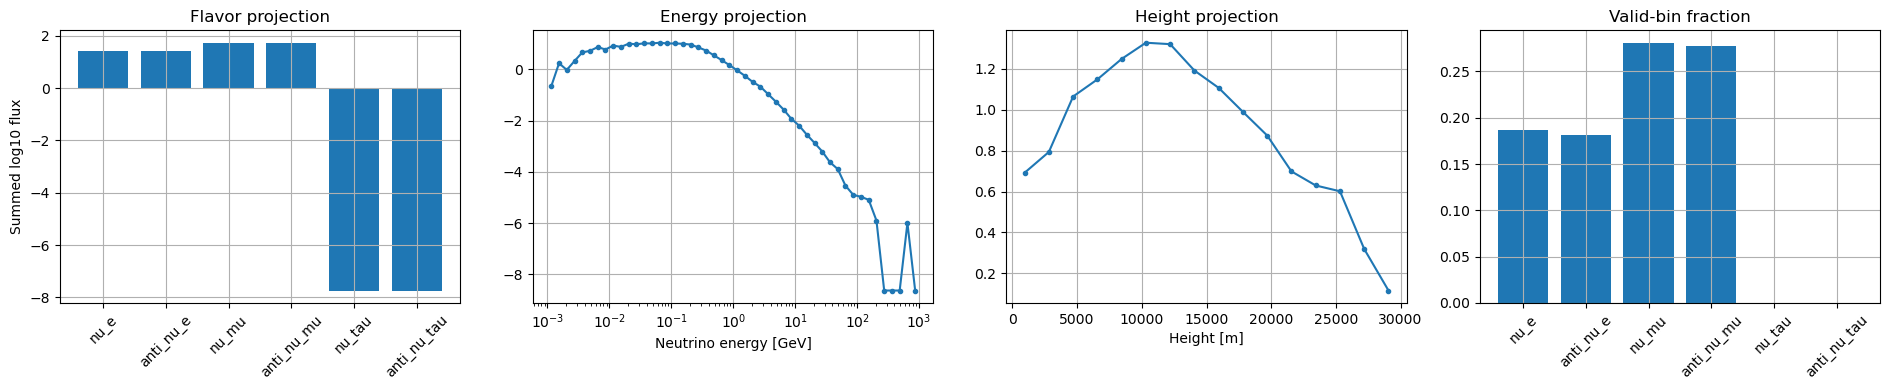

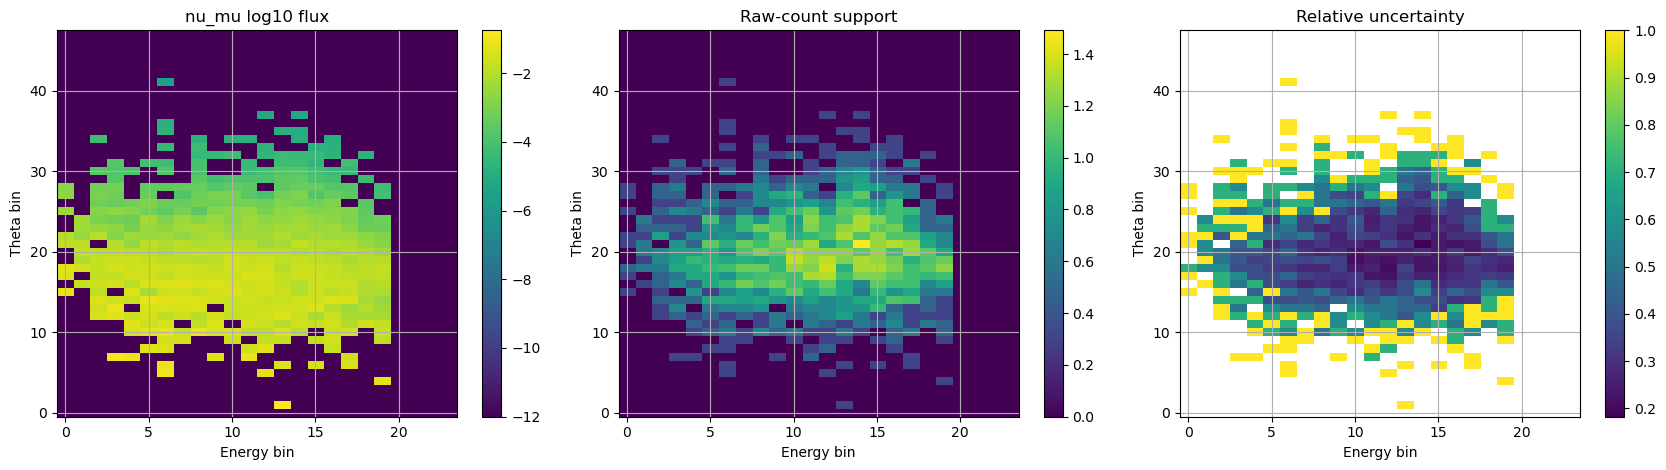

In [7]:
# Section 3 diagnostic: obtain, analyze, and visualize one diffusion-cube sample.
sample_dict = dataset.read_diagnostic_sample(0)
sample = sample_dict["x"]
assert tuple(sample.shape) == dataset.sample_shape
print("Sample keys:", list(sample_dict.keys()))
print(f"Sample tensor shape: {tuple(sample.shape)}")
print(f"Condition shape: {tuple(sample_dict['condition'].shape)}")
print(f"Valid mask fraction: {sample_dict['valid_mask'].float().mean().item():.4f}")
print(f"Raw count sum: {sample_dict['raw_counts'].sum().item():.0f}")
print(f"Sample normalized range: min={sample.min().item():.3f}, max={sample.max().item():.3f}")
print(f"Sample normalized moments: mean={sample.mean().item():.3f}, std={sample.std().item():.3f}")

raw_sample = dataset.denormalize(sample)
valid_mask = sample_dict["valid_mask"].numpy()
flavor_projection = np.log10(np.power(10,raw_sample).sum(axis=(1, 2, 3)))
energy_projection = np.log10(np.power(10,raw_sample).sum(axis=(0, 1, 2)))
height_projection = np.log10(np.power(10,raw_sample).sum(axis=(0, 2, 3)))
valid_by_flavor = valid_mask.mean(axis=(1, 2, 3))

fig, axes = plt.subplots(1, 4, figsize=(19, 4))
axes[0].bar(dataset.flavor_order, flavor_projection)
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_ylabel("Summed log10 flux")
axes[0].set_title("Flavor projection")
axes[1].plot(dataset.energy_centers, energy_projection, marker=".")
axes[1].set_xscale("log")
axes[1].set_xlabel("Neutrino energy [GeV]")
axes[1].set_title("Energy projection")
axes[2].plot(dataset.h_centers, height_projection, marker=".")
axes[2].set_xlabel("Height [m]")
axes[2].set_title("Height projection")
axes[3].bar(dataset.flavor_order, valid_by_flavor)
axes[3].tick_params(axis="x", rotation=45)
#axes[3].set_ylim(0, 1)
axes[3].set_title("Valid-bin fraction")
plt.tight_layout()
plt.show()

flavor_idx = dataset.flavor_order.index("nu_mu") if "nu_mu" in dataset.flavor_order else 0
height_idx = int(sample_dict["raw_counts"][flavor_idx].sum(dim=(1, 2)).argmax().item())
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
im0 = axes[0].imshow(raw_sample[flavor_idx, height_idx].T, origin="lower", aspect="auto", interpolation="nearest")
axes[0].set_title(f"{dataset.flavor_order[flavor_idx]} log10 flux")
axes[0].set_xlabel("Energy bin")
axes[0].set_ylabel("Theta bin")
fig.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(np.log10(sample_dict["raw_counts"][flavor_idx, height_idx].numpy().T + 1), origin="lower", aspect="auto", interpolation="nearest")
axes[1].set_title("Raw-count support")
axes[1].set_xlabel("Energy bin")
axes[1].set_ylabel("Theta bin")
fig.colorbar(im1, ax=axes[1])
im2 = axes[2].imshow(sample_dict["relative_uncertainty"][flavor_idx, height_idx].numpy().T, origin="lower", aspect="auto", interpolation="nearest")
axes[2].set_title("Relative uncertainty")
axes[2].set_xlabel("Energy bin")
axes[2].set_ylabel("Theta bin")
fig.colorbar(im2, ax=axes[2])
plt.tight_layout()
plt.show()


## 4. Training, Validation, and Test Dataloaders

This section creates reproducible train/validation/test splits over the block-sampled diffusion cubes stored in `neutrino_diffusion_cubes.h5`.


In [8]:
def split_lengths(n: int, train_fraction: float, val_fraction: float) -> tuple[int, int, int]:
    if n <= 0:
        raise ValueError("Cannot split an empty dataset")
    if n == 1:
        return 1, 0, 0
    if n == 2:
        return 1, 1, 0
    n_train = max(1, int(round(n * train_fraction)))
    n_val = max(1, int(round(n * val_fraction)))
    n_test = max(1, n - n_train - n_val)
    while n_train + n_val + n_test > n:
        if n_train >= n_val and n_train > 1:
            n_train -= 1
        elif n_val > 1:
            n_val -= 1
        else:
            n_test -= 1
    while n_train + n_val + n_test < n:
        n_train += 1
    return n_train, n_val, n_test


def dataloader_options(shuffle: bool, seed: int | None = None) -> dict[str, Any]:
    options: dict[str, Any] = {
        "shuffle": shuffle,
        "num_workers": CONFIG.num_workers,
        "pin_memory": torch.cuda.is_available(),
    }
    if seed is not None:
        options["generator"] = torch.Generator().manual_seed(seed)
    if CONFIG.num_workers > 0:
        options["persistent_workers"] = CONFIG.dataloader_persistent_workers
        options["prefetch_factor"] = CONFIG.dataloader_prefetch_factor
    return options


def make_loader(subset: Dataset, batch_size: int, shuffle: bool, seed: int | None = None) -> DataLoader:
    return DataLoader(subset, batch_size=batch_size, **dataloader_options(shuffle=shuffle, seed=seed))

n_train, n_val, n_test = split_lengths(len(dataset), CONFIG.train_fraction, CONFIG.val_fraction)
generator = torch.Generator().manual_seed(CONFIG.seed)
train_set, val_set, test_set = random_split(dataset, [n_train, n_val, n_test], generator=generator)
train_indices = np.asarray(train_set.indices, dtype=np.int64) if hasattr(train_set, "indices") else None
if CONFIG.normalize_condition:
    dataset.set_condition_normalization(train_indices)
# For very small smoke-test datasets, reuse train_set as evaluation fallback so later cells remain executable.
val_eval_set = val_set if len(val_set) else train_set
test_eval_set = test_set if len(test_set) else val_eval_set

train_loader = make_loader(train_set, batch_size=CONFIG.batch_size, shuffle=True, seed=CONFIG.seed)
val_loader = make_loader(val_eval_set, batch_size=CONFIG.batch_size, shuffle=False)
test_loader = make_loader(test_eval_set, batch_size=CONFIG.batch_size, shuffle=False)

print(f"Split sizes: train={len(train_set)}, val={len(val_set)}, test={len(test_set)}")
print(f"Evaluation fallback sizes: val_eval={len(val_eval_set)}, test_eval={len(test_eval_set)}")
print(f"Batches: train={len(train_loader)}, val={len(val_loader)}, test={len(test_loader)}")
print(f"DataLoader workers={CONFIG.num_workers}, "
      f"persistent={CONFIG.dataloader_persistent_workers and CONFIG.num_workers > 0}, "
      f"prefetch={CONFIG.dataloader_prefetch_factor if CONFIG.num_workers > 0 else 'disabled'}")


Split sizes: train=53, val=7, test=6
Evaluation fallback sizes: val_eval=7, test_eval=6
Batches: train=14, val=2, test=2
DataLoader workers=0, persistent=False, prefetch=disabled


In [9]:
# Section 4 diagnostic: inspect one dataloader batch.
batch = next(iter(train_loader))
print("x:", batch["x"].shape)
print("condition:", batch["condition"].shape)
print("valid_mask:", batch["valid_mask"].shape)
assert batch["x"].ndim == 5
assert tuple(batch["x"].shape[1:]) == dataset.sample_shape
assert batch["condition"].ndim == 2


x: torch.Size([4, 6, 16, 24, 48])
condition: torch.Size([4, 18])
valid_mask: torch.Size([4, 6, 16, 24, 48])


## 5. Model Definition

This section defines the conditional 3D U-Net used as the denoiser inside the diffusion process. A diffusion model learns to reverse a gradual noising process: during training, a clean neutrino cube `x0` is corrupted at a random timestep `t`, and the network predicts the Gaussian noise that was added. During generation, the process starts from pure noise and repeatedly applies the learned denoiser until a structured cube is recovered.

The model preserves the physical cube layout `(batch, flavor_channels, height, theta, energy)`. Flavor channels are treated as convolutional channels, while height, zenith angle, and energy are the 3D spatial axes. The timestep embedding tells the network how noisy the current cube is, and the Run 6 conditioning vector is projected into the same embedding space so generated cubes can depend on event-block metadata such as sample statistics and primary-shower summaries.

Key components:

- `SinusoidalTimeEmbedding`: encodes the diffusion timestep with smooth periodic features.
- `ResidualBlock3D`: applies 3D convolutions while injecting timestep and condition information.
- `Downsample3D` and `Upsample3D`: form the encoder-decoder path that captures both local bin structure and larger cube-scale correlations.
- Skip connections: carry high-resolution cube information from the encoder to the decoder.
- Final convolution: predicts the noise tensor with the same shape as the input cube.


### 5.1. SinusoidalTimeEmbedding

`SinusoidalTimeEmbedding` converts each integer diffusion timestep `t` into a continuous vector of sinusoidal features. The denoiser receives a different noise level at every training step, and this embedding is how the model knows whether it is seeing an almost-clean cube or a heavily noised cube.

Arguments:

- `dim`: size of the timestep embedding. Larger values give the model more capacity to distinguish fine differences between diffusion timesteps, but also increase the parameters in the following MLP layers. Too small a value can make early, middle, and late denoising regimes harder to separate; too large a value can overfit on a small dataset and slightly increase runtime.

Effect on the final model:

The output of this class is processed by `time_mlp` inside `DiffusionUNet3D` and injected into every residual block. If the timestep representation is weak, the model tends to average denoising behavior across noise levels; samples can become blurry, over-smoothed, or unstable during reverse diffusion.

In [10]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        half = self.dim // 2
        scale = math.log(10_000) / max(half - 1, 1)
        freqs = torch.exp(torch.arange(half, device=t.device) * -scale)
        args = t.float()[:, None] * freqs[None, :]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        if self.dim % 2:
            emb = F.pad(emb, (0, 1))
        return emb


### 5.2. ResidualBlock3D

`ResidualBlock3D` is the main feature-processing unit of the denoising U-Net. It applies two 3D convolutions with GroupNorm and SiLU activations, then adds a residual/skip path so the block learns a correction rather than a completely new representation.

Arguments:

- `in_channels`: number of feature channels entering the block. This must match the previous layer output.
- `out_channels`: number of feature channels produced by the block. Increasing it gives the model more representational capacity for correlations between flavor, height, zenith angle, and energy, but increases VRAM and runtime.
- `time_dim`: size of the combined time/condition embedding injected into the block. It must match the output dimension of `time_mlp`; larger values can encode richer conditioning but add parameters and may overfit if the dataset is small.

Effect on the final model:

These blocks determine how well the network can learn local 3D structure and condition-dependent corrections. If `out_channels` is too low, the model may fail to reproduce narrow energy peaks or flavor-dependent patterns. If it is too high relative to the number of samples, validation loss can improve slowly or generated cubes can memorize training artifacts.

In [11]:
class ResidualBlock3D(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, time_dim: int):
        super().__init__()
        groups_in = min(8, in_channels)
        groups_out = min(8, out_channels)
        self.norm1 = nn.GroupNorm(groups_in, in_channels)
        self.conv1 = nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1)
        self.time = nn.Linear(time_dim, out_channels)
        self.norm2 = nn.GroupNorm(groups_out, out_channels)
        self.conv2 = nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1)
        self.skip = nn.Conv3d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()

    def forward(self, x: torch.Tensor, time_emb: torch.Tensor) -> torch.Tensor:
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.time(F.silu(time_emb))[:, :, None, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)


### 5.3. Downsample3D

`Downsample3D` reduces the theta-energy resolution while preserving the height axis. In this notebook the convolution uses `kernel_size=(1, 4, 4)` and `stride=(1, 2, 2)`, so the model compresses angular and energy structure but keeps production-height bins intact.

Arguments:

- `channels`: number of feature channels to downsample. This does not change the channel count; it only changes spatial resolution.

Effect on the final model:

Downsampling expands the effective receptive field, allowing the model to learn broad correlations such as energy-spectrum shape and theta-energy bands. Preserving height avoids collapsing a very small height axis too aggressively. If downsampling were stronger, the model would be faster but could lose localized structures; if weaker, it would keep more detail but need more memory and might learn long-range energy/theta correlations less efficiently.

In [12]:
class Downsample3D(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.conv = nn.Conv3d(channels, channels, kernel_size=(1, 4, 4), stride=(1, 2, 2), padding=(0, 1, 1))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(x)


### 5.4. Upsample3D

`Upsample3D` restores spatial resolution in the decoder path. It uses trilinear interpolation to match a target shape and then applies a 3D convolution to refine the upsampled features.

Arguments:

- `channels`: number of feature channels being upsampled.
- `target_shape` in `forward`: the desired `(height, theta, energy)` shape, normally taken from the matching encoder feature map before concatenating the skip connection.

Effect on the final model:

This class controls how coarse bottleneck information is projected back to the original cube grid. Interpolation is stable and smooth, which helps avoid checkerboard artifacts. However, if the model already struggles with sparse support, upsampling can spread weak activation over too many bins; skip connections partially counteract that by restoring high-resolution encoder information.

In [13]:
class Upsample3D(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.conv = nn.Conv3d(channels, channels, kernel_size=3, padding=1)

    def forward(self, x: torch.Tensor, target_shape: tuple[int, int, int]) -> torch.Tensor:
        x = F.interpolate(x, size=target_shape, mode="trilinear", align_corners=False)
        return self.conv(x)


### 5.5. DiffusionUNet3D

`DiffusionUNet3D` is the full conditional denoiser. It receives a noisy cube `x_t`, a timestep `t`, and an optional condition vector with event-block metadata. It returns a tensor with the same shape as the input cube; depending on `CONFIG.prediction_target`, that tensor is interpreted as predicted noise, predicted velocity, or predicted clean cube. When `return_support=True`, it also returns `support_logits`, an auxiliary occupancy prediction for the same physical bins.

Arguments:

- `in_channels`: number of physical input channels, here the neutrino flavor channels. Changing this requires a matching dataset layout.
- `base_channels`: width of the U-Net. Higher values increase capacity and can improve detailed prediction, but raise VRAM usage and overfitting risk. Lower values train faster but may underfit energy and flavor structure.
- `time_dim`: size of the internal timestep/condition embedding. It must be large enough to encode the diffusion schedule and conditioning metadata.
- `condition_size`: number of scalar conditioning features in the HDF5 dataset. If this is zero, the model becomes unconditional.
- `condition_dim`: hidden size of the condition MLP. Larger values allow richer conditioning, but the condition vector must be normalized; otherwise large raw metadata values can dominate or destabilize training.

Effect on the final model:

This class defines the capacity, conditioning mechanism, and multi-scale structure of the denoiser. The generated cube quality depends strongly on the balance between `base_channels`, `time_dim`, training sample count, and sparsity of the target. The auxiliary support head helps the network learn where flux is allowed before learning precise flux values, which is important because the cube dataset is extremely sparse. Increasing capacity alone may produce smoother but still physically wrong support unless this occupancy structure is modeled.

In [14]:
class DiffusionUNet3D(nn.Module):
    def __init__(self, in_channels: int, base_channels: int, time_dim: int, condition_size: int = 0, condition_dim: int = 128):
        super().__init__()
        self.condition_size = int(condition_size)
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim * 4),
            nn.SiLU(),
            nn.Linear(time_dim * 4, time_dim),
        )
        self.condition_mlp = (
            nn.Sequential(
                nn.Linear(self.condition_size, condition_dim),
                nn.SiLU(),
                nn.Linear(condition_dim, time_dim),
            )
            if self.condition_size > 0
            else None
        )
        self.stem = nn.Conv3d(in_channels, base_channels, kernel_size=3, padding=1)
        self.down1 = ResidualBlock3D(base_channels, base_channels, time_dim)
        self.pool1 = Downsample3D(base_channels)
        self.down2 = ResidualBlock3D(base_channels, base_channels * 2, time_dim)
        self.pool2 = Downsample3D(base_channels * 2)
        self.mid = ResidualBlock3D(base_channels * 2, base_channels * 4, time_dim)
        self.up2 = Upsample3D(base_channels * 4)
        self.dec2 = ResidualBlock3D(base_channels * 4 + base_channels * 2, base_channels * 2, time_dim)
        self.up1 = Upsample3D(base_channels * 2)
        self.dec1 = ResidualBlock3D(base_channels * 2 + base_channels, base_channels, time_dim)
        self.out = nn.Sequential(
            nn.GroupNorm(min(8, base_channels), base_channels),
            nn.SiLU(),
            nn.Conv3d(base_channels, in_channels, kernel_size=3, padding=1),
        )
        self.support_out = nn.Sequential(
            nn.GroupNorm(min(8, base_channels), base_channels),
            nn.SiLU(),
            nn.Conv3d(base_channels, in_channels, kernel_size=3, padding=1),
        )

    def forward(self, x: torch.Tensor, t: torch.Tensor, condition: torch.Tensor | None = None, return_support: bool = False) -> torch.Tensor | tuple[torch.Tensor, torch.Tensor]:
        time_emb = self.time_mlp(t)
        if self.condition_mlp is not None:
            if condition is None:
                condition = torch.zeros(x.shape[0], self.condition_size, device=x.device, dtype=x.dtype)
            time_emb = time_emb + self.condition_mlp(condition.float())
        x0 = self.stem(x)
        x1 = self.down1(x0, time_emb)
        x2 = self.pool1(x1)
        x2 = self.down2(x2, time_emb)
        x3 = self.pool2(x2)
        x3 = self.mid(x3, time_emb)
        u2 = self.up2(x3, target_shape=x2.shape[-3:])
        u2 = self.dec2(torch.cat([u2, x2], dim=1), time_emb)
        u1 = self.up1(u2, target_shape=x1.shape[-3:])
        u1 = self.dec1(torch.cat([u1, x1], dim=1), time_emb)
        main = self.out(u1)
        if return_support:
            return main, self.support_out(u1)
        return main


### 5.6. Model Instantiation

This cell creates the concrete model used by the rest of the notebook. It derives `in_channels` and `condition_size` from the dataset, then applies the configured architecture values from `CONFIG`.

The most important configurable value here is `CONFIG.base_channels`, because it controls the U-Net width. `CONFIG.time_dim` and `CONFIG.condition_dim` control how strongly the diffusion timestep and event-block metadata can modulate the convolutional path. If generated samples ignore conditioning, `condition_dim` may be too small or the condition features may be weak; if training becomes unstable, the condition vector scale and normalization should be checked first.

In [15]:
in_channels = dataset.sample_shape[0]
condition_size = dataset.condition_dim
model = DiffusionUNet3D(in_channels, CONFIG.base_channels, CONFIG.time_dim, condition_size, CONFIG.condition_dim).to(DEVICE)
parameter_count = sum(p.numel() for p in model.parameters())
print(f"Input channels: {in_channels}")
print(f"Condition size: {condition_size}")
print(f"Model parameters: {parameter_count:,}")


Input channels: 6
Condition size: 18
Model parameters: 2,308,524


In [16]:
# Section 5 diagnostic: forward pass with one mini-batch, conditions, and random timesteps.
with torch.no_grad():
    x = batch["x"].to(DEVICE, non_blocking=True).float()
    condition = batch["condition"].to(DEVICE, non_blocking=True).float()
    t = torch.randint(0, CONFIG.diffusion_steps, (x.shape[0],), device=DEVICE)
    y = model(x, t, condition)
print(f"Input shape:  {tuple(x.shape)}")
print(f"Condition shape: {tuple(condition.shape)}")
print(f"Output shape: {tuple(y.shape)}")
assert y.shape == x.shape


Input shape:  (4, 6, 16, 24, 48)
Condition shape: (4, 18)
Output shape: (4, 6, 16, 24, 48)


## 6. Model Structure Visualization

This subsection combines three complementary views of the model:

- **Mermaid** gives a clean conceptual diagram for the diffusion workflow and the conditional 3D U-Net blocks.
- **torchinfo** runs a real forward-shape trace and reports layer shapes, parameters, trainable flags, and approximate memory use.
- **torchview** builds a visual computation graph from the actual PyTorch module and example inputs.

`torchinfo` and `torchview` are optional dependencies. If they are missing, the code cells print the installation command and continue with the rest of the notebook.


### 6.1. Mermaid Conceptual Diagram

```mermaid
flowchart LR
    D["Run 6 HDF5 Dataset<br/>neutrino_diffusion_cubes.h5"] --> X0["Clean cube x0<br/>log10 differential flux<br/>flavor x height x theta x energy"]
    X0 --> Q["Forward diffusion q(x_t | x0, t)<br/>add Gaussian noise"]
    T["Timestep t"] --> TE["Sinusoidal<br/>time embedding"]
    C["Condition vector c<br/>event statistics + primary metadata"] --> CE["Condition MLP"]
    TE --> E["Combined conditioning<br/>time + metadata"]
    CE --> E
    Q --> XT["Noisy cube x_t"]
    XT --> U["Conditional 3D U-Net denoiser"]
    E --> U

    subgraph U["Conditional 3D U-Net denoiser"]
        S["Stem 3D Conv"] --> R1["Residual Blocks"]
        R1 --> DS["Downsample"]
        DS --> R2["Residual Blocks"]
        R2 --> B["Bottleneck"]
        B --> US["Upsample"]
        R2 -. skip .-> US
        US --> R3["Residual Blocks"]
        R1 -. skip .-> R3
        R3 --> O["Output 3D Conv"]
    end

    U --> EPS["Predicted diffusion target<br/>epsilon, v, or x0"]
    U --> SUP["Support logits<br/>occupied-bin auxiliary head"]
    EPS --> LOSS["Diffusion objective<br/>weighted masked MSE"]
    SUP --> BCE["Support objective<br/>BCE / occupancy loss"]
    Z["Random noise x_T"] --> P["Reverse sampling<br/>T to 0 denoising steps"]
    P --> G["Generated neutrino cube"]
    EPS -. used at each reverse step .-> P
```


### 6.2. torchinfo Layer Summary

`torchinfo` executes a forward-shape trace with the same inputs used by the model during training. It reports the tensor sizes moving through the network, parameter counts by layer, trainable status, and a compact memory estimate.


In [17]:
# Section 6.2 diagnostic: torchinfo model summary.
summary_x = batch["x"][:1].to(DEVICE, non_blocking=True).float()
summary_t = torch.zeros(summary_x.shape[0], device=DEVICE, dtype=torch.long)
summary_condition = batch["condition"][:1].to(DEVICE, non_blocking=True).float()

try:
    from torchinfo import summary

    model_summary = summary(
        model,
        input_data=(summary_x, summary_t, summary_condition),
        col_names=("input_size", "output_size", "num_params", "trainable"),
        depth=4,
        verbose=1,
    )
   # print(model_summary)
except ImportError:
    print("torchinfo is not installed in this kernel.")
    print("Install it with: pip install torchinfo")
    print("\nFallback model hierarchy:")
    print(model)

print("\nCompact model summary")
print("-" * 72)
print(f"Input cube shape per sample: {dataset.sample_shape}")
print(f"Condition vector size: {condition_size}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
DiffusionUNet3D                          [1, 6, 16, 24, 48]        [1, 6, 16, 24, 48]        5,254                     True
├─Sequential: 1-1                        [1]                       [1, 128]                  --                        True
│    └─SinusoidalTimeEmbedding: 2-1      [1]                       [1, 128]                  --                        --
│    └─Linear: 2-2                       [1, 128]                  [1, 512]                  66,048                    True
│    └─SiLU: 2-3                         [1, 512]                  [1, 512]                  --                        --
│    └─Linear: 2-4                       [1, 512]                  [1, 128]                  65,664                    True
├─Sequential: 1-2                        [1, 18]                   [1, 128]                  --                        True
│    └─

### 6.3. torchview Computation Graph

`torchview` traces the actual PyTorch module with the same three inputs used by training: the noisy cube tensor, the timestep tensor, and the conditioning vector. This is more faithful than a hand-drawn diagram, and it can be exported as a PNG for reports or slides.


couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.

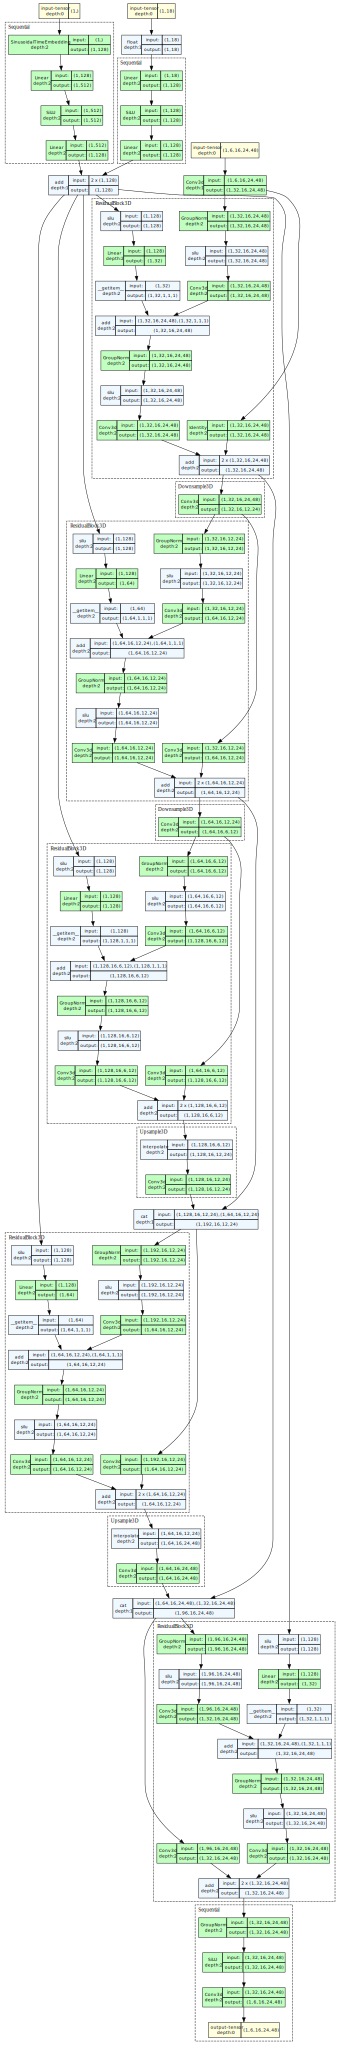

couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.

Saved torchview graph: V:\output\data\difussion\model\run_2\generated\diffusion_unet3d_torchview.png


In [18]:
# Section 6.3 diagnostic: torchview graph from the actual PyTorch model.
try:
    from IPython.display import display
    from torchview import draw_graph

    torchview_graph = draw_graph(
        model,
        input_data=(summary_x, summary_t, summary_condition),
        expand_nested=True,
        graph_name="DiffusionUNet3D",
        save_graph=False,
        device=str(DEVICE),
    )
    display(torchview_graph.visual_graph)

    graph_path = CONFIG.generated_dir / "diffusion_unet3d_torchview"
    torchview_graph.visual_graph.render(str(graph_path), format="png", cleanup=True)
    print(f"Saved torchview graph: {graph_path}.png")
except ImportError:
    print("torchview is not installed in this kernel.")
    print("Install it with: pip install torchview graphviz")
    print("On some systems you may also need the Graphviz system package.")
except Exception as exc:
    print("torchview graph generation failed.")
    print(f"Reason: {exc}")
    print("The torchinfo summary and Mermaid diagram above can still be used.")


## 7. Training Configuration and Auxiliary Functions

This section builds the DDPM noise schedule, adaptive learning-rate scheduler, mixed-precision support, EMA weights, checkpoint helpers, and a shared epoch function used by both training and validation.


### 7.1. GaussianDiffusion

`GaussianDiffusion` owns the mathematical schedule for the forward and reverse diffusion processes. It precomputes the beta schedule, cumulative alpha products, and posterior variances used by DDPM sampling.

During training, `q_sample` creates a noisy cube `x_t` from a clean normalized cube `x_0`, a sampled timestep, and random Gaussian noise. The U-Net is trained to predict that noise. During generation, `sample` starts from random noise and calls `p_sample` from the last timestep down to zero, using the trained U-Net and optional conditioning vector to progressively denoise the cube.


In [19]:
class GaussianDiffusion:
    def __init__(
        self,
        steps: int,
        beta_start: float,
        beta_end: float,
        device: torch.device,
        beta_schedule: str = "linear",
        prediction_target: str = "epsilon",
        min_snr_gamma: float | None = None,
    ):
        self.steps = int(steps)
        self.beta_schedule = beta_schedule.lower()
        self.prediction_target = prediction_target.lower()
        self.min_snr_gamma = min_snr_gamma
        if self.prediction_target not in {"epsilon", "v", "x0"}:
            raise ValueError("prediction_target must be 'epsilon', 'v', or 'x0'")
        if self.beta_schedule == "cosine":
            self.betas = self._cosine_betas(self.steps, device)
        elif self.beta_schedule == "linear":
            self.betas = torch.linspace(beta_start, beta_end, self.steps, device=device)
        else:
            raise ValueError("beta_schedule must be 'linear' or 'cosine'")
        self.betas = torch.clamp(self.betas, min=1e-8, max=0.999)
        self.alphas = 1.0 - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alpha_bars = torch.sqrt(self.alpha_bars)
        self.sqrt_one_minus_alpha_bars = torch.sqrt(1.0 - self.alpha_bars)
        self.sqrt_recip_alphas = torch.sqrt(1.0 / self.alphas)
        posterior = self.betas * (1.0 - torch.cat([torch.ones(1, device=device), self.alpha_bars[:-1]])) / (1.0 - self.alpha_bars)
        self.posterior_variance = torch.clamp(posterior, min=1e-20)
        self.snr = self.alpha_bars / (1.0 - self.alpha_bars).clamp_min(1e-12)

    @staticmethod
    def _cosine_betas(steps: int, device: torch.device, s: float = 0.008) -> torch.Tensor:
        x = torch.linspace(0, steps, steps + 1, device=device)
        alpha_bars = torch.cos(((x / steps) + s) / (1.0 + s) * math.pi * 0.5).pow(2)
        alpha_bars = alpha_bars / alpha_bars[0]
        return 1.0 - (alpha_bars[1:] / alpha_bars[:-1])

    def q_sample(self, x0: torch.Tensor, t: torch.Tensor, noise: torch.Tensor) -> torch.Tensor:
        a = self.sqrt_alpha_bars[t][:, None, None, None, None]
        b = self.sqrt_one_minus_alpha_bars[t][:, None, None, None, None]
        return a * x0 + b * noise

    def training_target(self, x0: torch.Tensor, t: torch.Tensor, noise: torch.Tensor) -> torch.Tensor:
        if self.prediction_target == "epsilon":
            return noise
        a = self.sqrt_alpha_bars[t][:, None, None, None, None]
        b = self.sqrt_one_minus_alpha_bars[t][:, None, None, None, None]
        if self.prediction_target == "v":
            return a * noise - b * x0
        return x0

    def predict_x0_and_noise(self, xt: torch.Tensor, t: torch.Tensor, model_output: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        a = self.sqrt_alpha_bars[t][:, None, None, None, None]
        b = self.sqrt_one_minus_alpha_bars[t][:, None, None, None, None]
        if self.prediction_target == "epsilon":
            pred_noise = model_output
            pred_x0 = (xt - b * pred_noise) / a.clamp_min(1e-12)
        elif self.prediction_target == "v":
            pred_noise = b * xt + a * model_output
            pred_x0 = a * xt - b * model_output
        else:
            pred_x0 = model_output
            pred_noise = (xt - a * pred_x0) / b.clamp_min(1e-12)
        return pred_x0, pred_noise

    def min_snr_weight(self, t: torch.Tensor) -> torch.Tensor:
        if self.min_snr_gamma is None or self.min_snr_gamma <= 0:
            return torch.ones_like(t, dtype=torch.float32)
        snr = self.snr[t]
        gamma = torch.full_like(snr, float(self.min_snr_gamma))
        clipped = torch.minimum(snr, gamma)
        if self.prediction_target == "epsilon":
            return clipped / snr.clamp_min(1e-12)
        if self.prediction_target == "v":
            return clipped / (snr + 1.0)
        return clipped

    @torch.no_grad()
    def p_sample(self, model: nn.Module, x: torch.Tensor, t_index: int, condition: torch.Tensor | None = None) -> torch.Tensor:
        t = torch.full((x.shape[0],), t_index, device=x.device, dtype=torch.long)
        model_output = model(x, t, condition)
        _, pred_noise = self.predict_x0_and_noise(x, t, model_output)
        beta_t = self.betas[t][:, None, None, None, None]
        sqrt_one_minus = self.sqrt_one_minus_alpha_bars[t][:, None, None, None, None]
        sqrt_recip = self.sqrt_recip_alphas[t][:, None, None, None, None]
        mean = sqrt_recip * (x - beta_t * pred_noise / sqrt_one_minus)
        if t_index == 0:
            return mean
        var = self.posterior_variance[t][:, None, None, None, None]
        return mean + torch.sqrt(var) * torch.randn_like(x)

    @torch.no_grad()
    def ddpm_sample(self, model: nn.Module, shape: tuple[int, ...], device: torch.device, condition: torch.Tensor | None = None) -> torch.Tensor:
        x = torch.randn(shape, device=device)
        for t_index in reversed(range(self.steps)):
            x = self.p_sample(model, x, t_index, condition)
        return x

    @torch.no_grad()
    def ddim_sample(self, model: nn.Module, shape: tuple[int, ...], device: torch.device, condition: torch.Tensor | None = None, sampling_steps: int = 50) -> torch.Tensor:
        x = torch.randn(shape, device=device)
        sampling_steps = max(1, min(int(sampling_steps), self.steps))
        timesteps = torch.linspace(self.steps - 1, 0, sampling_steps, device=device).round().long().unique_consecutive()
        if timesteps[-1].item() != 0:
            timesteps = torch.cat([timesteps, torch.zeros(1, device=device, dtype=torch.long)])

        for i, t_value in enumerate(timesteps):
            t_index = int(t_value.item())
            t = torch.full((shape[0],), t_index, device=device, dtype=torch.long)
            model_output = model(x, t, condition)
            pred_x0, pred_noise = self.predict_x0_and_noise(x, t, model_output)
            if i == len(timesteps) - 1:
                x = pred_x0
            else:
                next_t = timesteps[i + 1]
                alpha_next = self.alpha_bars[next_t]
                x = torch.sqrt(alpha_next) * pred_x0 + torch.sqrt(1.0 - alpha_next) * pred_noise
        return x

    @torch.no_grad()
    def sample(
        self,
        model: nn.Module,
        shape: tuple[int, ...],
        device: torch.device,
        condition: torch.Tensor | None = None,
        method: str = "ddpm",
        sampling_steps: int | None = None,
    ) -> torch.Tensor:
        model.eval()
        method = method.lower()
        if method == "ddim":
            return self.ddim_sample(model, shape, device, condition, sampling_steps or min(50, self.steps))
        if method != "ddpm":
            raise ValueError(f"Unknown sampling method: {method!r}. Use 'ddpm' or 'ddim'.")
        return self.ddpm_sample(model, shape, device, condition)


diffusion = GaussianDiffusion(
    CONFIG.diffusion_steps,
    CONFIG.beta_start,
    CONFIG.beta_end,
    DEVICE,
    CONFIG.beta_schedule,
    CONFIG.prediction_target,
    CONFIG.min_snr_gamma,
)


### 7.2. EMA

`EMA` keeps an exponential moving average of the model weights. Training weights can fluctuate from batch to batch, especially for diffusion models, while EMA weights usually provide smoother and more stable samples.

The training loop calls `ema.update(model)` after each optimizer step. For generation, `ema.copy_to(model_for_sampling)` copies the averaged weights into a separate sampling model, leaving the active training model unchanged.


In [20]:
class EMA:
    def __init__(self, model: nn.Module, decay: float):
        self.decay = decay
        self.shadow = {name: param.detach().clone() for name, param in model.named_parameters() if param.requires_grad}

    @torch.no_grad()
    def update(self, model: nn.Module) -> None:
        for name, param in model.named_parameters():
            if not param.requires_grad:
                continue
            self.shadow[name].mul_(self.decay).add_(param.detach(), alpha=1.0 - self.decay)

    @torch.no_grad()
    def copy_to(self, model: nn.Module) -> None:
        for name, param in model.named_parameters():
            if name in self.shadow:
                param.copy_(self.shadow[name])


ema = EMA(model, CONFIG.ema_decay)


### 7.3. run_epoch and Optimization Helpers

`run_epoch` is the shared loop used for both training and validation. When an optimizer is provided, it performs a full training step: sample timesteps, add diffusion noise, predict the noise with the conditional U-Net, compute the masked MSE loss, backpropagate, clip gradients, update weights, and refresh EMA. When `optimizer=None`, the same function runs in validation mode without gradient updates.

This subsection also defines reusable helpers for dataloader creation, mixed-precision control, masked MSE, and checkpoint writing. The actual optimizer, scheduler, scaler, diffusion schedule, EMA object, and model instance are created inside `train_diffusion_model` in Section 8 so hyperparameter experiments can instantiate clean independent runs.


In [21]:
AMP_DEVICE_TYPE = "cuda" if torch.cuda.is_available() else "cpu"


def make_dataloaders(batch_size: int, seed: int = CONFIG.seed) -> dict[str, DataLoader]:
    """Create train/validation/test dataloaders for a requested batch size."""
    train = make_loader(train_set, batch_size=batch_size, shuffle=True, seed=seed)
    val = make_loader(val_eval_set, batch_size=batch_size, shuffle=False)
    test = make_loader(test_eval_set, batch_size=batch_size, shuffle=False)
    return {"train": train, "val": val, "test": test}


def weighted_mse(
    pred: torch.Tensor,
    target: torch.Tensor,
    valid_mask: torch.Tensor | None,
    min_weight: float,
    loss_weight: torch.Tensor | None = None,
    timestep_weight: torch.Tensor | None = None,
) -> torch.Tensor:
    err = (pred - target).pow(2)
    weights = torch.ones_like(err)
    if valid_mask is not None:
        weights = valid_mask.to(dtype=err.dtype)
        if min_weight > 0:
            weights = torch.clamp(weights, min=min_weight)
    if loss_weight is not None:
        weights = weights * loss_weight.to(dtype=err.dtype)
    if timestep_weight is not None:
        weights = weights * timestep_weight.to(dtype=err.dtype)[:, None, None, None, None]
    return (err * weights).sum() / weights.sum().clamp_min(1.0)




def support_bce_loss(logits: torch.Tensor, support_mask: torch.Tensor, pos_weight: float | None = None) -> torch.Tensor:
    target = support_mask.to(dtype=logits.dtype)
    if pos_weight is None:
        positives = target.sum().detach()
        negatives = target.numel() - positives
        pos_weight_tensor = (negatives / positives.clamp_min(1.0)).clamp(1.0, 1_000.0).to(logits.device)
    else:
        pos_weight_tensor = torch.tensor(float(pos_weight), device=logits.device, dtype=logits.dtype)
    return F.binary_cross_entropy_with_logits(logits, target, pos_weight=pos_weight_tensor)

# Backward-compatible alias used by later diagnostic cells.
def masked_mse(pred: torch.Tensor, target: torch.Tensor, valid_mask: torch.Tensor | None, min_weight: float) -> torch.Tensor:
    return weighted_mse(pred, target, valid_mask, min_weight)


def projection_rmse(pred_x0: torch.Tensor, x0: torch.Tensor, valid_mask: torch.Tensor | None = None) -> dict[str, float]:
    if valid_mask is not None:
        mask = valid_mask.to(dtype=x0.dtype)
        pred_x0 = pred_x0 * mask
        x0 = x0 * mask
    dims = {
        "flavor_projection_rmse": (2, 3, 4),
        "height_projection_rmse": (1, 3, 4),
        "theta_projection_rmse": (1, 2, 4),
        "energy_projection_rmse": (1, 2, 3),
    }
    metrics = {}
    for name, axes in dims.items():
        pred_proj = pred_x0.mean(dim=axes)
        real_proj = x0.mean(dim=axes)
        metrics[name] = float(torch.sqrt(torch.mean((pred_proj - real_proj).pow(2))).detach().cpu())
    return metrics


def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    diffusion: GaussianDiffusion,
    optimizer: torch.optim.Optimizer | None = None,
    scaler: torch.amp.GradScaler | None = None,
    ema: EMA | None = None,
    device: torch.device = DEVICE,
    grad_clip_norm: float | None = None,
    use_valid_mask_loss: bool = CONFIG.use_valid_mask_loss,
    min_valid_loss_weight: float = CONFIG.min_valid_loss_weight,
    amp_enabled: bool | None = None,
    amp_device_type: str = AMP_DEVICE_TYPE,
    collect_physical_metrics: bool = False,
) -> dict[str, float]:
    is_train = optimizer is not None
    model.train(is_train)
    total_loss = 0.0
    total_main_loss = 0.0
    total_support_loss = 0.0
    total_items = 0
    physical_totals: dict[str, float] = {}
    physical_items = 0
    start = time.time()
    if amp_enabled is None:
        amp_enabled = CONFIG.use_amp and amp_device_type == "cuda"

    for batch in loader:
        x0 = batch["x"].to(device, non_blocking=True).float()
        condition = batch["condition"].to(device, non_blocking=True).float()
        valid_mask = batch["valid_mask"].to(device, non_blocking=True) if use_valid_mask_loss else None
        support_mask = batch.get("support_mask")
        support_mask = support_mask.to(device, non_blocking=True) if support_mask is not None else None
        loss_weight = batch.get("loss_weight")
        loss_weight = loss_weight.to(device, non_blocking=True).float() if loss_weight is not None else None
        t = torch.randint(0, diffusion.steps, (x0.shape[0],), device=device)
        noise = torch.randn_like(x0)
        xt = diffusion.q_sample(x0, t, noise)
        target = diffusion.training_target(x0, t, noise)
        timestep_weight = diffusion.min_snr_weight(t)

        with torch.set_grad_enabled(is_train):
            with torch.amp.autocast(amp_device_type, enabled=amp_enabled):
                if CONFIG.use_support_head and support_mask is not None:
                    pred, support_logits = model(xt, t, condition, return_support=True)
                    main_loss = weighted_mse(pred, target, valid_mask, min_valid_loss_weight, loss_weight, timestep_weight)
                    support_loss = support_bce_loss(support_logits, support_mask, CONFIG.support_pos_weight)
                    loss = main_loss + CONFIG.support_loss_weight * support_loss
                else:
                    pred = model(xt, t, condition)
                    support_loss = torch.zeros((), device=device, dtype=pred.dtype)
                    main_loss = weighted_mse(pred, target, valid_mask, min_valid_loss_weight, loss_weight, timestep_weight)
                    loss = main_loss

        if is_train:
            optimizer.zero_grad(set_to_none=True)
            if scaler is not None and scaler.is_enabled():
                scaler.scale(loss).backward()
                if grad_clip_norm is not None:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                if grad_clip_norm is not None:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)
                optimizer.step()
            if ema is not None:
                ema.update(model)

        if collect_physical_metrics:
            with torch.no_grad():
                pred_x0, _ = diffusion.predict_x0_and_noise(xt, t, pred.detach())
                batch_metrics = projection_rmse(pred_x0, x0, valid_mask)
            for key, value in batch_metrics.items():
                physical_totals[key] = physical_totals.get(key, 0.0) + value * x0.shape[0]
            physical_items += x0.shape[0]

        total_loss += loss.item() * x0.shape[0]
        total_main_loss += main_loss.item() * x0.shape[0]
        total_support_loss += support_loss.item() * x0.shape[0]
        total_items += x0.shape[0]

    metrics = {
        "loss": total_loss / max(total_items, 1),
        "main_loss": total_main_loss / max(total_items, 1),
        "support_loss": total_support_loss / max(total_items, 1),
        "seconds": time.time() - start,
    }
    if collect_physical_metrics and physical_items:
        metrics.update({key: value / physical_items for key, value in physical_totals.items()})
    return metrics


def save_checkpoint(path: Path, epoch: int, model: nn.Module, optimizer: torch.optim.Optimizer, history: pd.DataFrame, experiment_config: dict[str, Any] | None = None) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "config": CONFIG.__dict__,
            "experiment_config": experiment_config or {},
            "history": history.to_dict(orient="list"),
            "normalization": {
                "mean": dataset.mean,
                "std": dataset.std,
                "condition_mean": dataset.condition_mean.tolist() if dataset.condition_mean is not None else [],
                "condition_std": dataset.condition_std.tolist() if dataset.condition_std is not None else [],
            },
            "dataset": {
                "path": str(dataset.path),
                "target": dataset.target,
                "sample_shape": dataset.sample_shape,
                "condition_columns": dataset.condition_columns,
                "flavor_order": dataset.flavor_order,
            },
        },
        path,
    )


def load_checkpoint_into_model(path: Path, model: nn.Module, device: torch.device = DEVICE) -> dict[str, Any]:
    """Load a saved diffusion checkpoint into `model` and return the checkpoint metadata."""
    checkpoint = torch.load(path, map_location=device)
    load_result = model.load_state_dict(checkpoint["model_state"], strict=False)
    if load_result.missing_keys or load_result.unexpected_keys:
        print("Checkpoint/model key mismatch detected.")
        print("Missing keys:", load_result.missing_keys)
        print("Unexpected keys:", load_result.unexpected_keys)
        print("For physically meaningful sampling, retrain with the active architecture and configuration.")
    model.to(device)
    model.eval()
    return checkpoint


In [22]:
# Section 7 diagnostic: one no-update validation-style pass on a small batch.
tmp_loader = make_loader(Subset(dataset, [0]), batch_size=1, shuffle=False)
metrics = run_epoch(model, tmp_loader, diffusion, optimizer=None, scaler=None, ema=None)
print(metrics)
assert np.isfinite(metrics["loss"])


{'loss': 1.86991548538208, 'main_loss': 1.5619361400604248, 'support_loss': 1.2319172620773315, 'seconds': 0.050995826721191406}


In [23]:
s = dataset[0]
for key, value in s.items():
    print(key)
x=s['x']
cond = s['condition']
print(x.shape, cond.shape)
print(cond, s['valid_mask'].shape, s['index'])

x
condition
valid_mask
support_mask
loss_weight
index
torch.Size([6, 16, 24, 48]) torch.Size([18])
tensor([ 0.0000,  0.0000,  0.3237, -0.0074, -0.4070,  0.4520,  3.6037,  3.0065,
        -0.7437, -1.3252, -0.2849, -1.3885, -1.0722, -0.7457, -0.4797,  0.2186,
        -0.5981,  1.3398]) torch.Size([6, 16, 24, 48]) tensor(0)


## 8. Main Model Training Loop

This section wraps the complete training procedure in `train_diffusion_model`. The function creates a fresh model, dataloaders, optimizer, scheduler, diffusion schedule, scaler, and EMA object for each run. The default call at the end trains the main model used by Sections 9 and 10, while Section 12 reuses the same function for hyperparameter and optimization experiments.


In [24]:
def train_diffusion_model(
    experiment_name: str = "default",
    epochs: int = CONFIG.epochs,
    learning_rate: float = CONFIG.learning_rate,
    batch_size: int = CONFIG.batch_size,
    weight_decay: float = CONFIG.weight_decay,
    grad_clip_norm: float = CONFIG.grad_clip_norm,
    diffusion_steps: int = CONFIG.diffusion_steps,
    beta_start: float = CONFIG.beta_start,
    beta_end: float = CONFIG.beta_end,
    beta_schedule: str = CONFIG.beta_schedule,
    prediction_target: str = CONFIG.prediction_target,
    min_snr_gamma: float | None = CONFIG.min_snr_gamma,
    base_channels: int = CONFIG.base_channels,
    time_dim: int = CONFIG.time_dim,
    condition_dim: int = CONFIG.condition_dim,
    ema_decay: float = CONFIG.ema_decay,
    use_amp: bool = CONFIG.use_amp,
    use_valid_mask_loss: bool = CONFIG.use_valid_mask_loss,
    min_valid_loss_weight: float = CONFIG.min_valid_loss_weight,
    scheduler_patience: int = CONFIG.scheduler_patience,
    scheduler_factor: float = CONFIG.scheduler_factor,
    seed: int = CONFIG.seed,
    save_checkpoints: bool = True,
    best_model_path: Path | None = None,
    last_model_path: Path | None = None,
    verbose: bool = True,
) -> dict[str, Any]:
    """Train one diffusion model configuration and return artifacts plus comparable metrics."""
    seed_everything(seed)
    experiment_slug = "".join(ch if ch.isalnum() or ch in "-_" else "_" for ch in experiment_name).strip("_") or "experiment"
    experiment_config = dict(
        experiment_name=experiment_name,
        epochs=epochs,
        learning_rate=learning_rate,
        batch_size=batch_size,
        weight_decay=weight_decay,
        grad_clip_norm=grad_clip_norm,
        diffusion_steps=diffusion_steps,
        beta_start=beta_start,
        beta_end=beta_end,
        beta_schedule=beta_schedule,
        prediction_target=prediction_target,
        min_snr_gamma=min_snr_gamma,
        base_channels=base_channels,
        time_dim=time_dim,
        condition_dim=condition_dim,
        ema_decay=ema_decay,
        use_amp=use_amp,
        use_valid_mask_loss=use_valid_mask_loss,
        min_valid_loss_weight=min_valid_loss_weight,
        use_support_head=CONFIG.use_support_head,
        support_loss_weight=CONFIG.support_loss_weight,
        support_pos_weight=CONFIG.support_pos_weight,
        scheduler_patience=scheduler_patience,
        scheduler_factor=scheduler_factor,
        seed=seed,
    )

    loaders = make_dataloaders(
                            batch_size=batch_size, 
                            seed=seed
    )
    local_model = DiffusionUNet3D(
        in_channels, 
        base_channels, 
        time_dim, 
        condition_size, 
        condition_dim
    ).to(DEVICE)
    local_diffusion = GaussianDiffusion(
        diffusion_steps,
        beta_start, 
        beta_end, 
        DEVICE, 
        beta_schedule, 
        prediction_target, 
        min_snr_gamma
    )
    local_optimizer = torch.optim.AdamW(
        local_model.parameters(), 
        lr=learning_rate, 
        weight_decay=weight_decay
    )
    local_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(local_optimizer, 
                                                                 mode="min", 
                                                                 factor=scheduler_factor, 
                                                                 patience=scheduler_patience
                                                                )
    amp_enabled = use_amp and AMP_DEVICE_TYPE == "cuda"
    local_scaler = torch.amp.GradScaler(
        AMP_DEVICE_TYPE, 
        enabled=amp_enabled
    )
    local_ema = EMA(
        local_model,
        ema_decay
    )

    local_history_rows: list[dict[str, float | int | str]] = []
    best_val = float("inf")
    best_epoch = 0
    best_path = Path(best_model_path) if best_model_path is not None else CONFIG.checkpoint_dir / f"best_{experiment_slug}.pt"
    last_path = Path(last_model_path) if last_model_path is not None else CONFIG.checkpoint_dir / f"last_{experiment_slug}.pt"

    for epoch in range(1, epochs + 1):
        train_metrics = run_epoch(
            local_model,
            loaders["train"],
            local_diffusion,
            optimizer=local_optimizer,
            scaler=local_scaler,
            ema=local_ema,
            grad_clip_norm=grad_clip_norm,
            use_valid_mask_loss=use_valid_mask_loss,
            min_valid_loss_weight=min_valid_loss_weight,
            amp_enabled=amp_enabled,
        )
        val_metrics = run_epoch(
            local_model,
            loaders["val"],
            local_diffusion,
            optimizer=None,
            scaler=None,
            ema=None,
            use_valid_mask_loss=use_valid_mask_loss,
            min_valid_loss_weight=min_valid_loss_weight,
            amp_enabled=amp_enabled,
            collect_physical_metrics=True,
        )
        local_scheduler.step(val_metrics["loss"])
        lr = local_optimizer.param_groups[0]["lr"]
        row = {
            "experiment_name": experiment_name,
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_main_loss": train_metrics.get("main_loss", train_metrics["loss"]),
            "train_support_loss": train_metrics.get("support_loss", 0.0),
            "val_loss": val_metrics["loss"],
            "val_main_loss": val_metrics.get("main_loss", val_metrics["loss"]),
            "val_support_loss": val_metrics.get("support_loss", 0.0),
            "train_seconds": train_metrics["seconds"],
            "val_seconds": val_metrics["seconds"],
            "lr": lr,
        }
        for key, value in val_metrics.items():
            if key.endswith("_projection_rmse"):
                row[f"val_{key}"] = value
        local_history_rows.append(row)
        local_history = pd.DataFrame(local_history_rows)

        if save_checkpoints:
            save_checkpoint(last_path, epoch, local_model, local_optimizer, local_history, experiment_config)
        if val_metrics["loss"] < best_val:
            best_val = val_metrics["loss"]
            best_epoch = epoch
            if save_checkpoints:
                save_checkpoint(best_path, epoch, local_model, local_optimizer, local_history, experiment_config)

        if verbose:
            phys = f" | val_energy_rmse={val_metrics.get('energy_projection_rmse', float('nan')):.4f}" if "energy_projection_rmse" in val_metrics else ""
            support_msg = f" | support={val_metrics.get('support_loss', 0.0):.4f}" if CONFIG.use_support_head else ""
            print(f"[{experiment_name}] epoch={epoch:03d} | train_loss={train_metrics['loss']:.6f} | val_loss={val_metrics['loss']:.6f}{support_msg}{phys} | lr={lr:.2e} | t={train_metrics['seconds']+val_metrics['seconds']:.1f} s.")

    local_history = pd.DataFrame(local_history_rows)
    result = {
        "experiment_name": experiment_name,
        "config": experiment_config,
        "model": local_model,
        "ema": local_ema,
        "diffusion": local_diffusion,
        "optimizer": local_optimizer,
        "scheduler": local_scheduler,
        "scaler": local_scaler,
        "history": local_history,
        "best_val": best_val,
        "best_epoch": best_epoch,
        "best_path": best_path,
        "last_path": last_path,
        "train_loader": loaders["train"],
        "val_loader": loaders["val"],
        "test_loader": loaders["test"],
        "final_train_loss": float(local_history["train_loss"].iloc[-1]),
        "final_val_loss": float(local_history["val_loss"].iloc[-1]),
        "parameter_count": sum(p.numel() for p in local_model.parameters()),
    }
    if verbose:
        print(f"Best validation loss: {best_val:.6f}  (epoch = {best_epoch})")
        print(f"Best checkpoint: {best_path if save_checkpoints else 'not saved'}")
    return result


In [25]:
print('Starting Training Model: ', CONFIG.epochs,'epochs')
training_result = train_diffusion_model(experiment_name="default", 
                                        epochs = 50,
                                        learning_rate = 0.000373,
                                        save_checkpoints=True,
                                        best_model_path=CONFIG.model_file,
                                        last_model_path=CONFIG.model_last_epoch,
                                        verbose=True
                                       )
model = training_result["model"]
ema = training_result["ema"]
diffusion = training_result["diffusion"]
optimizer = training_result["optimizer"]
scheduler = training_result["scheduler"]
scaler = training_result["scaler"]
history = training_result["history"]
history_rows = history.to_dict(orient="records")
best_val = training_result["best_val"]
best_epoch = training_result["best_epoch"]
best_path = training_result["best_path"]
last_path = training_result["last_path"]
train_loader = training_result["train_loader"]
val_loader = training_result["val_loader"]
test_loader = training_result["test_loader"]

Starting Training Model:  50 epochs
[default] epoch=001 | train_loss=1.640081 | val_loss=1.182886 | support=0.8177 | val_energy_rmse=0.0386 | lr=3.73e-04 | t=1.5 s.
[default] epoch=002 | train_loss=1.085696 | val_loss=0.903135 | support=0.5675 | val_energy_rmse=0.0653 | lr=3.73e-04 | t=1.4 s.
[default] epoch=003 | train_loss=0.905101 | val_loss=0.872415 | support=0.4365 | val_energy_rmse=0.0311 | lr=3.73e-04 | t=1.4 s.
[default] epoch=004 | train_loss=0.812235 | val_loss=0.745922 | support=0.3955 | val_energy_rmse=0.0392 | lr=3.73e-04 | t=1.5 s.
[default] epoch=005 | train_loss=0.666747 | val_loss=0.531530 | support=0.3819 | val_energy_rmse=0.0140 | lr=3.73e-04 | t=1.5 s.
[default] epoch=006 | train_loss=0.733675 | val_loss=0.761914 | support=0.3884 | val_energy_rmse=0.0552 | lr=3.73e-04 | t=1.4 s.
[default] epoch=007 | train_loss=0.829690 | val_loss=0.767770 | support=0.4212 | val_energy_rmse=0.0248 | lr=3.73e-04 | t=1.5 s.
[default] epoch=008 | train_loss=0.758582 | val_loss=0.870226

## 9. Training Validation

This section evaluates the trained model on validation and test dataloaders using the same epoch loop with validation arguments. It also plots loss curves and stores the training history.


In [26]:
@torch.no_grad()
def baseline_zero_noise_loss(loader, diffusion, device=DEVICE, use_valid_mask_loss: bool = CONFIG.use_valid_mask_loss, min_valid_loss_weight: float = CONFIG.min_valid_loss_weight):
    total_loss = 0.0
    total_items = 0

    for batch in loader:
        x0 = batch["x"].to(device).float()
        valid_mask = batch["valid_mask"].to(device) if use_valid_mask_loss else None
        t = torch.randint(0, diffusion.steps, (x0.shape[0],), device=device)
        noise = torch.randn_like(x0)
        target = diffusion.training_target(x0, t, noise)
        pred = torch.zeros_like(target)
        timestep_weight = diffusion.min_snr_weight(t)
        loss_weight = batch.get("loss_weight")
        loss_weight = loss_weight.to(device).float() if loss_weight is not None else None
        loss = weighted_mse(pred, target, valid_mask, min_valid_loss_weight, loss_weight, timestep_weight)

        total_loss += loss.item() * x0.shape[0]
        total_items += x0.shape[0]

    return total_loss / max(total_items, 1)

torch.manual_seed(123)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(123)

baseline_loss = baseline_zero_noise_loss(val_loader, diffusion)
model_loss = run_epoch(model, val_loader, diffusion, optimizer=None, scaler=None, ema=None)["loss"]

print(f"Zero-noise baseline loss:       {baseline_loss:.6f}")
print(f"Model validation loss (Final):  {model_loss:.6f}")
print(f"Improvement ratio:              {model_loss / baseline_loss:.3f}")

Zero-noise baseline loss:       3.027137
Model validation loss (Final):  0.191075
Improvement ratio:              0.063


In [27]:
# Section 9: load the best checkpoint before validation and test evaluation.
if not CONFIG.model_file.exists():
    raise FileNotFoundError(f"Best model checkpoint not found: {CONFIG.model_file}")

best_checkpoint = load_checkpoint_into_model(CONFIG.model_file, model, DEVICE)
best_epoch = int(best_checkpoint.get("epoch", best_epoch))
history_rows = best_checkpoint.get("history", history.to_dict(orient="list"))
if isinstance(history_rows, dict):
    history_rows = pd.DataFrame(history_rows).to_dict(orient="records")
print(f"Loaded best model checkpoint for validation: {CONFIG.model_file}")
print(f"Best checkpoint epoch: {best_epoch}")

val_final = run_epoch(model, val_loader, diffusion, optimizer=None, scaler=None, ema=None)
test_final = run_epoch(model, test_loader, diffusion, optimizer=None, scaler=None, ema=None)
print(f"Final validation metrics: {val_final}")
print(f"Final test metrics: {test_final}")

history = pd.DataFrame(history_rows)
history_path = CONFIG.generated_dir / "training_history.csv"
history.to_csv(history_path, index=False)
display(history.tail())
print(f"Saved history: {history_path}")


Loaded best model checkpoint for validation: V:\output\data\difussion\model\run_2\model_difussion_neutrino_cube3D.h5
Best checkpoint epoch: 43
Final validation metrics: {'loss': 0.11045556196144649, 'main_loss': 0.049814785697630475, 'support_loss': 0.24256310718400137, 'seconds': 0.04199790954589844}
Final test metrics: {'loss': 0.1809612512588501, 'main_loss': 0.13154993454615274, 'support_loss': 0.19764525691668192, 'seconds': 0.04800105094909668}


,experiment_name,epoch,train_loss,train_main_loss,train_support_loss,val_loss,val_main_loss,val_support_loss,train_seconds,val_seconds,lr,val_flavor_projection_rmse,val_height_projection_rmse,val_theta_projection_rmse,val_energy_projection_rmse
38,default,39,0.284487,0.219634,0.259412,0.221469,0.162480,0.235957,1.318011,0.040990,0.000191,0.006909,0.004136,0.004793,0.006627
39,default,40,0.252025,0.193432,0.234374,0.199845,0.148810,0.204140,1.319998,0.041000,0.000153,0.006209,0.004670,0.005466,0.006978
40,default,41,0.229538,0.173004,0.226133,0.322610,0.261539,0.244288,1.321089,0.040988,0.000153,0.005763,0.004049,0.004630,0.006188
41,default,42,0.182894,0.126140,0.227017,0.206746,0.150695,0.224204,1.351001,0.041011,0.000153,0.007906,0.006004,0.006587,0.010570
42,default,43,0.176222,0.122840,0.213528,0.157791,0.107437,0.201418,1.321011,0.041002,0.000153,0.004297,0.003945,0.004268,0.005375


Saved history: V:\output\data\difussion\model\run_2\generated\training_history.csv


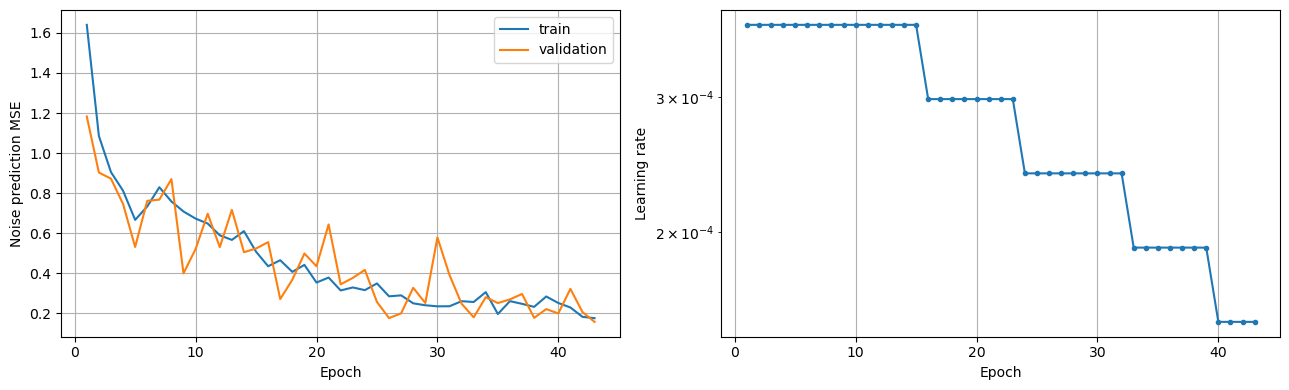

In [28]:
# Section 9 diagnostic: visualize optimization dynamics.
if not history.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history["epoch"], history["train_loss"], label="train")
    axes[0].plot(history["epoch"], history["val_loss"], label="validation")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Noise prediction MSE")
    axes[0].legend()
    axes[1].plot(history["epoch"], history["lr"], marker=".")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Learning rate")
    axes[1].set_yscale("log")
    plt.tight_layout()
    plt.show()
else:
    print("Training history is empty; run Section 8 first.")


## 10. Result Visualization

This section samples new neutrino cubes, denormalizes them back into log10 differential-flux space, compares generated and reference projections, and writes generated cubes to HDF5.


In [29]:
# Section 10: generate samples with EMA weights and condition vectors from real cube samples.
sample_batch = next(iter(test_loader))
if sample_batch["condition"].shape[0] < CONFIG.sample_count:
    sample_batch = next(iter(train_loader))

sample_condition_batch = sample_batch["condition"][:CONFIG.sample_count].to(DEVICE).float()
sample_indices = sample_batch["index"][:CONFIG.sample_count].detach().cpu().numpy().astype(int)
actual_sample_count = sample_condition_batch.shape[0]
sample_shape = (actual_sample_count, *dataset.sample_shape)
reference_cubes = np.stack([dataset.read_raw_sample(int(idx)) for idx in sample_indices], axis=0)

model_for_sampling = DiffusionUNet3D(
    in_channels,
    CONFIG.base_channels,
    CONFIG.time_dim,
    condition_size,
    CONFIG.condition_dim,
).to(DEVICE)
model_for_sampling.load_state_dict(model.state_dict())
ema.copy_to(model_for_sampling)

generated_norm = diffusion.sample(
    model_for_sampling,
    sample_shape,
    DEVICE,
    sample_condition_batch,
    method=CONFIG.sample_method,
    sampling_steps=CONFIG.sample_steps,
)
generated = dataset.denormalize(generated_norm)
print(f"Generated normalized shape: {tuple(generated_norm.shape)}")
print(f"Generated denormalized range: min={generated.min():.3f}, max={generated.max():.3f}")
print(f"Condition batch shape: {tuple(sample_condition_batch.shape)}")
print(f"Reference sample indices: {sample_indices.tolist()}")

torch.manual_seed(123)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(123)

baseline_loss = baseline_zero_noise_loss(val_loader, diffusion)
model_loss = run_epoch(model_for_sampling, val_loader, diffusion, optimizer=None, scaler=None, ema=None)["loss"]

print(f"\nZero-noise baseline loss:        {baseline_loss:.6f}")
print(f"Model validation loss (best):    {model_loss:.6f}")
print(f"Improvement ratio:               {model_loss / baseline_loss:.3f}")


Generated normalized shape: (4, 6, 16, 24, 48)
Generated denormalized range: min=-27.046, max=9.587
Condition batch shape: (4, 18)
Reference sample indices: [28, 45, 38, 26]

Zero-noise baseline loss:        3.027137
Model validation loss (best):    0.228586
Improvement ratio:               0.076


### 10.1. Projection Scale Definitions

The generated and reference tensors in this section are already denormalized back to `log10_differential_flux`. Each cube value is therefore a logarithmic flux value at one `(flavor, height, theta, energy)` bin, not a raw particle count.

The projection plots collapse some cube axes to make the result easier to inspect:

- **By flavor**: the Y axis is the mean `log10_differential_flux` over height, theta, and energy for each flavor channel.
- **By energy**: the Y axis is the mean `log10_differential_flux` over flavor, height, and theta for each energy bin. The X axis is logarithmic because the energy grid is logarithmic in GeV.
- **Theta-energy map**: the color scale is the mean `log10_differential_flux` over height for one selected flavor. X is energy-bin index, Y is theta-bin index.

Using means instead of raw sums keeps the scale independent of the number of bins being collapsed. These plots are diagnostic summaries: they compare shape, range, and coherence, but they are not integrated physical fluxes.


C:\Users\juanr\AppData\Local\Temp\ipykernel_42272\3257034697.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


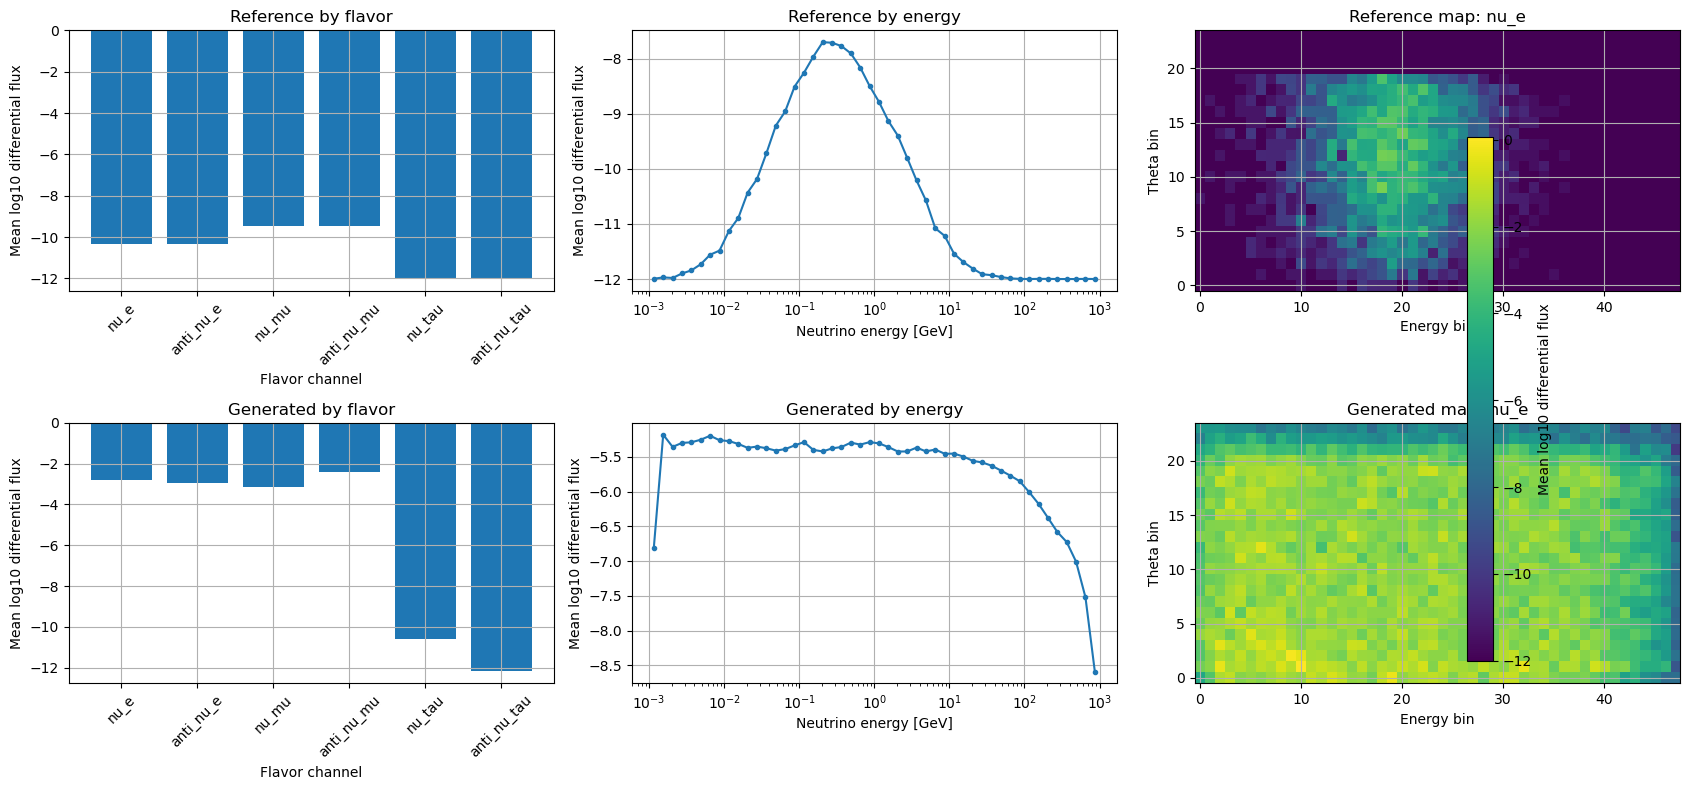

Projection scale definitions
------------------------------------------------------------------------
By flavor Y axis: mean log10 differential flux over height, theta, and energy bins.
By energy Y axis: mean log10 differential flux over flavor, height, and theta bins.
Map color scale: mean log10 differential flux over height for the selected flavor.
These are diagnostic averages in log space, not raw counts and not integrated physical fluxes.


In [30]:
# Section 10.1 diagnostic: compare generated projections with one reference cube sample.
ref = reference_cubes[0]
first = generated[0]
flavor_names = dataset.flavor_order or [f"ch_{i}" for i in range(ref.shape[0])]

# The cube values are log10 differential flux. We use means over collapsed axes so
# the vertical/color scales are comparable and do not depend on how many bins exist.
ref_by_flavor = ref.mean(axis=(1, 2, 3))
first_by_flavor = first.mean(axis=(1, 2, 3))
ref_by_energy = ref.mean(axis=(0, 1, 2))
first_by_energy = first.mean(axis=(0, 1, 2))
ref_map = ref[0].mean(axis=0)
first_map = first[0].mean(axis=0)

vmin = float(np.nanmin([ref_map.min(), first_map.min()]))
vmax = float(np.nanmax([ref_map.max(), first_map.max()]))

fig, axes = plt.subplots(2, 3, figsize=(17, 8))
axes[0, 0].bar(flavor_names, ref_by_flavor)
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].set_title("Reference by flavor")
axes[0, 0].set_ylabel("Mean log10 differential flux")
axes[0, 1].plot(dataset.energy_centers, ref_by_energy, marker=".")
axes[0, 1].set_xscale("log")
axes[0, 1].set_title("Reference by energy")
axes[0, 1].set_ylabel("Mean log10 differential flux")
im_ref = axes[0, 2].imshow(ref_map, aspect="auto", origin="lower", vmin=vmin, vmax=vmax)
axes[0, 2].set_title(f"Reference map: {flavor_names[0]}")

axes[1, 0].bar(flavor_names, first_by_flavor)
axes[1, 0].tick_params(axis="x", rotation=45)
axes[1, 0].set_title("Generated by flavor")
axes[1, 0].set_ylabel("Mean log10 differential flux")
axes[1, 1].plot(dataset.energy_centers, first_by_energy, marker=".")
axes[1, 1].set_xscale("log")
axes[1, 1].set_title("Generated by energy")
axes[1, 1].set_ylabel("Mean log10 differential flux")
im_gen = axes[1, 2].imshow(first_map, aspect="auto", origin="lower", vmin=vmin, vmax=vmax)
axes[1, 2].set_title(f"Generated map: {flavor_names[0]}")

for ax in axes[:, 0]:
    ax.set_xlabel("Flavor channel")
for ax in axes[:, 1]:
    ax.set_xlabel("Neutrino energy [GeV]")
for ax in axes[:, 2]:
    ax.set_xlabel("Energy bin")
    ax.set_ylabel("Theta bin")
fig.colorbar(im_ref, ax=axes[:, 2], label="Mean log10 differential flux", shrink=0.85)
plt.tight_layout()
plt.show()

print("Projection scale definitions")
print("-" * 72)
print("By flavor Y axis: mean log10 differential flux over height, theta, and energy bins.")
print("By energy Y axis: mean log10 differential flux over flavor, height, and theta bins.")
print("Map color scale: mean log10 differential flux over height for the selected flavor.")
print("These are diagnostic averages in log space, not raw counts and not integrated physical fluxes.")


### 10.2. Quantitative Generation Metrics

This subsection computes ten diagnostics that are useful for diffusion models on physics cubes. The first two metrics validate the denoising objective; the next four compare physically meaningful projections; the support and range metrics check whether generated cubes occupy plausible regions of log-flux space; and the final two metrics compare distributional shape.

The metrics are computed between `generated` cubes and the corresponding `reference_cubes` selected from the same dataloader batch used for conditioning. They are diagnostic, not a replacement for domain validation: a good model should improve the denoising baseline, match projection-level physics, stay inside the real value range, and preserve multi-axis correlations in visual checks.


In [31]:
# Section 10.2: ten quantitative metrics for generated neutrino cubes.
def rmse(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.sqrt(np.mean(np.square(np.asarray(a, dtype=float) - np.asarray(b, dtype=float)))))


def normalize_nonnegative(values: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    arr = np.asarray(values, dtype=np.float64)
    arr = arr - np.nanmin(arr)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    total = arr.sum()
    if total <= eps:
        return np.full_like(arr, 1.0 / max(arr.size, 1), dtype=np.float64)
    return arr / total


def wasserstein_1d_from_weights(grid: np.ndarray, p: np.ndarray, q: np.ndarray) -> float:
    grid = np.asarray(grid, dtype=np.float64)
    p = normalize_nonnegative(p)
    q = normalize_nonnegative(q)
    cdf_delta = np.cumsum(p - q)
    widths = np.diff(grid)
    if widths.size == 0:
        return float(np.abs(cdf_delta).mean())
    widths = np.concatenate([widths, widths[-1:]])
    return float(np.sum(np.abs(cdf_delta) * widths))


def cube_feature_matrix(cubes: np.ndarray) -> np.ndarray:
    """Build compact physical feature vectors from cube projections."""
    flavor = cubes.mean(axis=(2, 3, 4))
    height = cubes.mean(axis=(1, 3, 4))
    theta = cubes.mean(axis=(1, 2, 4))
    energy = cubes.mean(axis=(1, 2, 3))
    global_stats = np.stack(
        [
            cubes.mean(axis=(1, 2, 3, 4)),
            cubes.std(axis=(1, 2, 3, 4)),
            cubes.min(axis=(1, 2, 3, 4)),
            cubes.max(axis=(1, 2, 3, 4)),
        ],
        axis=1,
    )
    return np.concatenate([global_stats, flavor, height, theta, energy], axis=1)


def rbf_mmd(x: np.ndarray, y: np.ndarray, eps: float = 1e-12) -> float:
    """Biased RBF-kernel MMD on standardized feature vectors."""
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    both = np.vstack([x, y])
    mean = both.mean(axis=0, keepdims=True)
    std = both.std(axis=0, keepdims=True) + eps
    x = (x - mean) / std
    y = (y - mean) / std
    both = np.vstack([x, y])
    d2 = np.sum((both[:, None, :] - both[None, :, :]) ** 2, axis=-1)
    median_d2 = np.median(d2[d2 > 0]) if np.any(d2 > 0) else 1.0
    gamma = 1.0 / (2.0 * median_d2 + eps)
    kxx = np.exp(-gamma * np.sum((x[:, None, :] - x[None, :, :]) ** 2, axis=-1)).mean()
    kyy = np.exp(-gamma * np.sum((y[:, None, :] - y[None, :, :]) ** 2, axis=-1)).mean()
    kxy = np.exp(-gamma * np.sum((x[:, None, :] - y[None, :, :]) ** 2, axis=-1)).mean()
    return float(kxx + kyy - 2.0 * kxy)


real_eval = np.asarray(reference_cubes, dtype=np.float32)
gen_eval = np.asarray(generated, dtype=np.float32)
assert real_eval.shape == gen_eval.shape

real_flavor = real_eval.mean(axis=(0, 2, 3, 4))
gen_flavor = gen_eval.mean(axis=(0, 2, 3, 4))
real_height = real_eval.mean(axis=(0, 1, 3, 4))
gen_height = gen_eval.mean(axis=(0, 1, 3, 4))
real_theta = real_eval.mean(axis=(0, 1, 2, 4))
gen_theta = gen_eval.mean(axis=(0, 1, 2, 4))
real_energy = real_eval.mean(axis=(0, 1, 2, 3))
gen_energy = gen_eval.mean(axis=(0, 1, 2, 3))

support_threshold = max(-299.0, float(np.nanpercentile(real_eval, 1.0)))
real_support_fraction = float((real_eval > support_threshold).mean())
gen_support_fraction = float((gen_eval > support_threshold).mean())
real_min = float(np.nanmin(real_eval))
real_max = float(np.nanmax(real_eval))
range_outside_fraction = float(((gen_eval < real_min) | (gen_eval > real_max)).mean())

metrics = {
    "val_noise_mse": float(model_loss),
    "baseline_ratio": float(model_loss / baseline_loss),
    "energy_projection_rmse": rmse(real_energy, gen_energy),
    "theta_projection_rmse": rmse(real_theta, gen_theta),
    "height_projection_rmse": rmse(real_height, gen_height),
    "flavor_projection_rmse": rmse(real_flavor, gen_flavor),
    "support_error": abs(gen_support_fraction - real_support_fraction),
    "range_error": range_outside_fraction,
    "wasserstein_energy": wasserstein_1d_from_weights(dataset.energy_centers, real_energy, gen_energy),
    "mmd_features": rbf_mmd(cube_feature_matrix(real_eval), cube_feature_matrix(gen_eval)),
}

metric_descriptions = {
    "val_noise_mse": "Validation denoising MSE; lower means better noise prediction.",
    "baseline_ratio": "Model denoising MSE divided by zero-noise baseline MSE; below 1 means the model beats the naive baseline.",
    "energy_projection_rmse": "RMSE between real and generated mean log10-flux energy projections.",
    "theta_projection_rmse": "RMSE between real and generated mean log10-flux theta projections.",
    "height_projection_rmse": "RMSE between real and generated mean log10-flux height projections.",
    "flavor_projection_rmse": "RMSE between real and generated mean log10-flux flavor projections.",
    "support_error": f"Absolute difference in occupied-bin fraction using support threshold {support_threshold:.3f}.",
    "range_error": "Fraction of generated values outside the min/max range of the reference cubes.",
    "wasserstein_energy": "1D Wasserstein distance between normalized real and generated energy profiles.",
    "mmd_features": "RBF-kernel MMD between compact physical feature vectors; lower means closer distributions.",
}

metrics_table = pd.DataFrame(
    [
        {"metric": name, "value": value, "description": metric_descriptions[name]}
        for name, value in metrics.items()
    ]
)
display(metrics_table)

metrics_path = CONFIG.generated_dir / "generation_metrics.csv"
metrics_table.to_csv(metrics_path, index=False)
print(f"Saved metrics: {metrics_path}")
print(f"Support threshold: {support_threshold:.6f}")
print(f"Real support fraction: {real_support_fraction:.6f}")
print(f"Generated support fraction: {gen_support_fraction:.6f}")
print(f"Reference range: [{real_min:.6f}, {real_max:.6f}]")
print(f"Generated range: [{float(np.nanmin(gen_eval)):.6f}, {float(np.nanmax(gen_eval)):.6f}]")


,metric,value,description
0,val_noise_mse,0.228586,Validation denoising MSE; lower means better n...
1,baseline_ratio,0.075512,Model denoising MSE divided by zero-noise base...
2,energy_projection_rmse,5.072710,RMSE between real and generated mean log10-flu...
3,theta_projection_rmse,4.926029,RMSE between real and generated mean log10-flu...
4,height_projection_rmse,4.887861,RMSE between real and generated mean log10-flu...
5,flavor_projection_rmse,5.761047,RMSE between real and generated mean log10-flu...
6,support_error,0.697996,Absolute difference in occupied-bin fraction u...
7,range_error,0.220886,Fraction of generated values outside the min/m...
8,wasserstein_energy,33.418647,1D Wasserstein distance between normalized rea...
9,mmd_features,0.795483,RBF-kernel MMD between compact physical featur...


Saved metrics: V:\output\data\difussion\model\run_2\generated\generation_metrics.csv
Support threshold: -12.000000
Real support fraction: 0.154546
Generated support fraction: 0.852541
Reference range: [-12.000000, 0.041916]
Generated range: [-27.046051, 9.586839]


In [32]:
# Section 10 storage: save generated cubes with original grid metadata and conditioning vectors.
generated_path = CONFIG.generated_dir / "generated_neutrino_cubes.h5"
with h5py.File(generated_path, "w") as h5:
    h5.attrs["description"] = "Generated CORSIKA-like log10 neutrino flux cubes from Run 7 conditional diffusion model"
    h5.attrs["source_dataset"] = str(CONFIG.dataset_path)
    h5.attrs["source_target"] = f"samples/{CONFIG.cube_target}"
    h5.attrs["normalization_mean"] = dataset.mean
    h5.attrs["normalization_std"] = dataset.std
    h5.attrs["axis_order"] = "sample, channel/flavor, height, theta, energy"
    h5.create_dataset("generated/log10_differential_flux", data=generated, compression="gzip")
    h5.create_dataset("generated/condition", data=sample_condition_batch.detach().cpu().numpy(), compression="gzip")
    h5.create_dataset("reference/sample_index", data=sample_indices)
    h5.create_dataset("reference/log10_differential_flux", data=reference_cubes, compression="gzip")
    h5.create_dataset("grid/energy_centers_gev", data=dataset.energy_centers)
    h5.create_dataset("grid/theta_centers_deg", data=dataset.theta_centers)
    h5.create_dataset("grid/h_centers_m", data=dataset.h_centers)
    dt = h5py.string_dtype("utf-8")
    h5.create_dataset("grid/flavor_order", data=np.asarray(dataset.flavor_order, dtype=object), dtype=dt)
    h5.create_dataset("samples/condition_columns", data=np.asarray(dataset.condition_columns, dtype=object), dtype=dt)
    h5.create_dataset("metrics/name", data=np.asarray(list(metrics.keys()), dtype=object), dtype=dt)
    h5.create_dataset("metrics/value", data=np.asarray(list(metrics.values()), dtype=np.float64))
print(f"Saved generated cubes: {generated_path}")


Saved generated cubes: V:\output\data\difussion\model\run_2\generated\generated_neutrino_cubes.h5


## 11. Additional Diagnostic Tests

This section defines additional checks to explain discrepancies between reference and generated cubes. These tests are designed to separate three possible failure modes: a configuration/checkpoint mismatch, a denoising model that has not learned the training distribution, and a dataset representation that is too sparse or too dominated by empty bins.

### 11.1. Checkpoint and Configuration Consistency Test

This test compares the configuration stored in the loaded checkpoint with the current notebook configuration. The critical fields are `prediction_target`, `beta_schedule`, `diffusion_steps`, normalization statistics, `sample_shape`, `condition_columns`, and `flavor_order`.

**Expected result:**

The checkpoint and notebook should agree on the diffusion target and schedule. A model trained to predict `epsilon` with a linear schedule cannot be sampled correctly as a `v`-prediction model with a cosine schedule.

**Possible problems:**

If these values differ, generated samples can have the wrong scale, overly broad support, or physically implausible energy spectra even if the training loss looked reasonable. In that case, retrain from scratch or load the model with the exact configuration used during training.

,field,current,checkpoint,matches
0,diffusion_steps,300,300,True
1,beta_start,0.0001,0.0001,True
2,beta_end,0.02,0.02,True
3,beta_schedule,cosine,cosine,True
4,prediction_target,v,v,True
5,min_snr_gamma,5.0,5.0,True
6,cube_target,log10_differential_flux_valid,<missing>,False
7,base_channels,32,32,True
8,time_dim,128,128,True
9,condition_dim,128,128,True


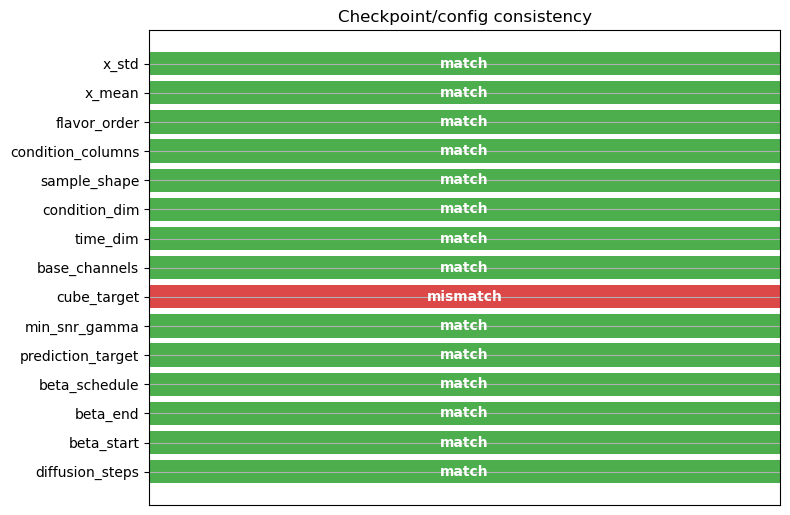

In [33]:
# Section 11.1 diagnostic: compare checkpoint metadata with the active notebook configuration.
def _as_list(value):
    if value is None:
        return []
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (list, tuple)):
        return list(value)
    return value

checkpoint_path = CONFIG.model_file
checkpoint_metadata = {}
if checkpoint_path.exists():
    checkpoint_metadata = torch.load(checkpoint_path, map_location="cpu")
else:
    print(f"Checkpoint not found: {checkpoint_path}")

checkpoint_config = checkpoint_metadata.get("experiment_config", {}) or checkpoint_metadata.get("config", {}) if checkpoint_metadata else {}
checkpoint_dataset = checkpoint_metadata.get("dataset", {}) if checkpoint_metadata else {}
checkpoint_norm = checkpoint_metadata.get("normalization", {}) if checkpoint_metadata else {}

comparison_rows = []
config_checks = {
    "diffusion_steps": CONFIG.diffusion_steps,
    "beta_start": CONFIG.beta_start,
    "beta_end": CONFIG.beta_end,
    "beta_schedule": CONFIG.beta_schedule,
    "prediction_target": CONFIG.prediction_target,
    "min_snr_gamma": CONFIG.min_snr_gamma,
    "cube_target": CONFIG.cube_target,
    "base_channels": CONFIG.base_channels,
    "time_dim": CONFIG.time_dim,
    "condition_dim": CONFIG.condition_dim,
}
for key, current_value in config_checks.items():
    checkpoint_value = checkpoint_config.get(key, "<missing>")
    comparison_rows.append({
        "field": key,
        "current": current_value,
        "checkpoint": checkpoint_value,
        "matches": str(current_value) == str(checkpoint_value),
    })

metadata_checks = {
    "sample_shape": dataset.sample_shape,
    "condition_columns": dataset.condition_columns,
    "flavor_order": dataset.flavor_order,
    "x_mean": dataset.mean,
    "x_std": dataset.std,
}
checkpoint_metadata_values = {
    "sample_shape": tuple(checkpoint_dataset.get("sample_shape", ())),
    "condition_columns": checkpoint_dataset.get("condition_columns", []),
    "flavor_order": checkpoint_dataset.get("flavor_order", []),
    "x_mean": checkpoint_norm.get("mean", "<missing>"),
    "x_std": checkpoint_norm.get("std", "<missing>"),
}
for key, current_value in metadata_checks.items():
    checkpoint_value = checkpoint_metadata_values.get(key, "<missing>")
    current_comp = _as_list(current_value)
    checkpoint_comp = _as_list(checkpoint_value)
    comparison_rows.append({
        "field": key,
        "current": str(current_comp)[:180],
        "checkpoint": str(checkpoint_comp)[:180],
        "matches": current_comp == checkpoint_comp if key not in {"x_mean", "x_std"} else np.isclose(float(current_value), float(checkpoint_value), rtol=1e-5, atol=1e-6) if checkpoint_value != "<missing>" else False,
    })

checkpoint_comparison = pd.DataFrame(comparison_rows)
display(checkpoint_comparison)

fig, ax = plt.subplots(figsize=(8, max(3, 0.35 * len(checkpoint_comparison))))
colors = np.where(checkpoint_comparison["matches"].to_numpy(dtype=bool), "tab:green", "tab:red")
ax.barh(checkpoint_comparison["field"], np.ones(len(checkpoint_comparison)), color=colors, alpha=0.85)
ax.set_xlim(0, 1)
ax.set_xticks([])
ax.set_title("Checkpoint/config consistency")
for i, ok in enumerate(checkpoint_comparison["matches"]):
    ax.text(0.5, i, "match" if ok else "mismatch", ha="center", va="center", color="white", fontweight="bold")
plt.tight_layout()
plt.show()

if not checkpoint_comparison["matches"].all():
    print("WARNING: configuration or metadata mismatches found. Sampling results may not be physically meaningful until the model is retrained or loaded with matching settings.")
else:
    print("Checkpoint metadata is consistent with the active notebook configuration.")


### 11.2. Tiny Overfit Test on 1-4 Cubes

This test trains the model on a tiny subset, usually one to four cube samples, for many optimization steps. The goal is not generalization; the goal is to verify that the architecture, loss, masks, normalization, and diffusion target are capable of representing the data at all.

**Expected result:**

The training loss should decrease strongly, and generated or reconstructed projections should approach the selected reference cubes. The model should reproduce the support pattern and the main energy peak for those samples.

**Possible problems:**

If the model cannot overfit a few cubes, the issue is likely in the target representation, masking, loss weighting, diffusion objective, or model wiring. If it overfits well but validation samples are poor, the issue is more likely data volume, split strategy, conditioning, or insufficient regularization/generalization.

epoch=001 tiny_loss=4.585373
epoch=006 tiny_loss=1.621564
epoch=012 tiny_loss=1.316807
epoch=018 tiny_loss=1.026834
epoch=024 tiny_loss=0.685748
epoch=030 tiny_loss=0.923563
epoch=036 tiny_loss=0.697461
epoch=042 tiny_loss=0.820010
epoch=048 tiny_loss=0.698133
epoch=054 tiny_loss=0.903798
epoch=060 tiny_loss=0.682888


,epoch,loss,main_loss,support_loss,seconds,flavor_projection_rmse,height_projection_rmse,theta_projection_rmse,energy_projection_rmse
55,56,0.724170,0.600830,0.493360,0.111989,0.029267,0.025147,0.026264,0.037413
56,57,0.889660,0.768324,0.485342,0.109998,0.020884,0.019902,0.018374,0.025741
57,58,0.774762,0.653847,0.483661,0.109003,0.016381,0.020287,0.016202,0.021056
58,59,0.896629,0.784014,0.450462,0.109998,0.017729,0.020269,0.017516,0.021953
59,60,0.682888,0.567127,0.463044,0.107001,0.012412,0.020342,0.014565,0.018566


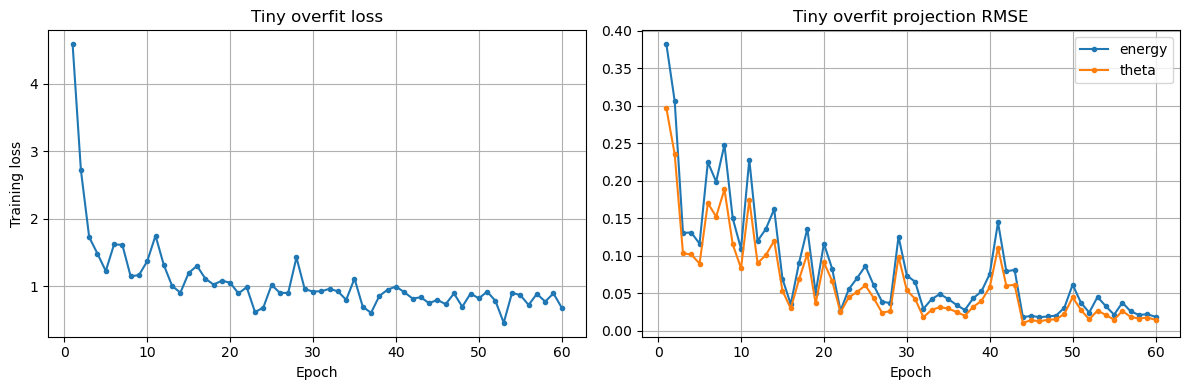

In [34]:
# Section 11.2 diagnostic: optional tiny overfit test.
RUN_TINY_OVERFIT_TEST = True
TINY_OVERFIT_SAMPLES = 4
TINY_OVERFIT_EPOCHS = 60
TINY_OVERFIT_LR = 4e-4

if RUN_TINY_OVERFIT_TEST:
    tiny_indices = list(range(min(TINY_OVERFIT_SAMPLES, len(dataset))))
    tiny_loader = make_loader(Subset(dataset, tiny_indices), batch_size=len(tiny_indices), shuffle=True, seed=CONFIG.seed)
    tiny_model = DiffusionUNet3D(in_channels, CONFIG.base_channels, CONFIG.time_dim, condition_size, CONFIG.condition_dim).to(DEVICE)
    tiny_diffusion = GaussianDiffusion(
        CONFIG.diffusion_steps,
        CONFIG.beta_start,
        CONFIG.beta_end,
        DEVICE,
        CONFIG.beta_schedule,
        CONFIG.prediction_target,
        CONFIG.min_snr_gamma,
    )
    tiny_optimizer = torch.optim.AdamW(tiny_model.parameters(), lr=TINY_OVERFIT_LR, weight_decay=0.0)
    tiny_history = []
    for epoch in range(1, TINY_OVERFIT_EPOCHS + 1):
        metrics_epoch = run_epoch(
            tiny_model,
            tiny_loader,
            tiny_diffusion,
            optimizer=tiny_optimizer,
            scaler=None,
            ema=None,
            grad_clip_norm=CONFIG.grad_clip_norm,
            collect_physical_metrics=True,
        )
        tiny_history.append({"epoch": epoch, **metrics_epoch})
        if epoch % max(1, TINY_OVERFIT_EPOCHS // 10) == 0 or epoch == 1:
            print(f"epoch={epoch:03d} tiny_loss={metrics_epoch['loss']:.6f}")

    tiny_history = pd.DataFrame(tiny_history)
    display(tiny_history.tail())
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(tiny_history["epoch"], tiny_history["loss"], marker=".")
    axes[0].set_title("Tiny overfit loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Training loss")
    if "energy_projection_rmse" in tiny_history:
        axes[1].plot(tiny_history["epoch"], tiny_history["energy_projection_rmse"], marker=".", label="energy")
        axes[1].plot(tiny_history["epoch"], tiny_history["theta_projection_rmse"], marker=".", label="theta")
        axes[1].set_title("Tiny overfit projection RMSE")
        axes[1].set_xlabel("Epoch")
        axes[1].legend()
    plt.tight_layout()
    plt.show()
else:
    print("Tiny overfit test is disabled. Set RUN_TINY_OVERFIT_TEST = True to run this intentionally expensive diagnostic.")
    preview_indices = list(range(min(TINY_OVERFIT_SAMPLES, len(dataset))))
    preview = pd.DataFrame({"sample_index": preview_indices, "purpose": "tiny-overfit candidate"})
    display(preview)


### 11.3. Denoising Reconstruction Test

This test evaluates `pred_x0` from partially noised validation cubes instead of sampling from pure noise. It answers whether the network can denoise real samples when the starting point is near the data manifold.

**Expected result:**

For moderate timesteps, reconstructed `pred_x0` should preserve the reference energy peak, flavor hierarchy, and theta-energy support better than unconditional generated samples.

**Possible problems:**

If denoising reconstruction is good but full sampling is poor, the sampler, number of sampling steps, schedule, or accumulated reverse-process error is the main suspect. If denoising is also poor, the model has not learned the data distribution or the loss does not align with the physical structure.

,flavor_projection_rmse,height_projection_rmse,theta_projection_rmse,energy_projection_rmse,timestep,normalized_mse
0,0.001247,0.000975,0.001108,0.001505,10,0.010819
1,0.001815,0.001288,0.001680,0.002123,50,0.194246
2,0.003354,0.001867,0.002417,0.003088,150,1.472645
3,0.005080,0.007592,0.006913,0.028696,299,2.923405


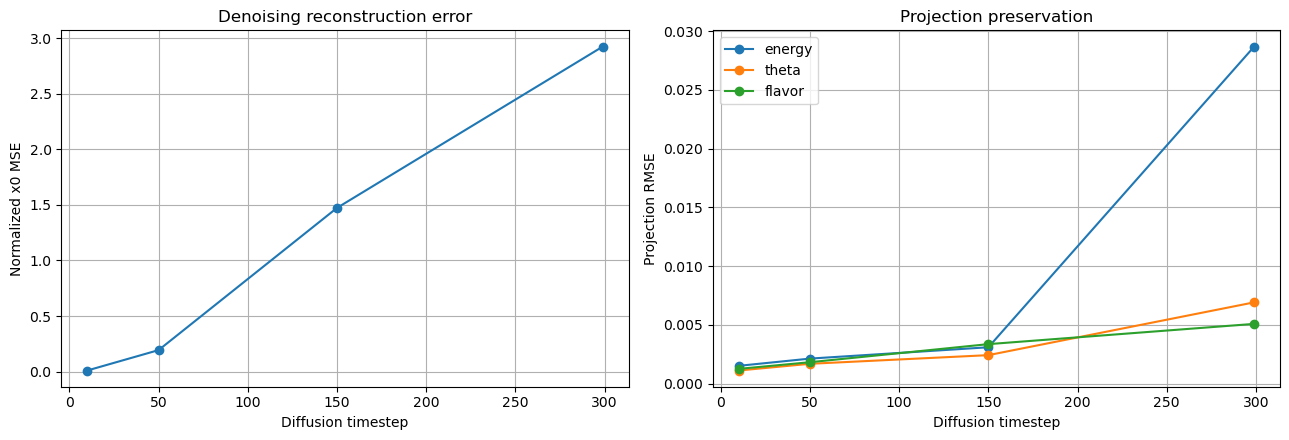

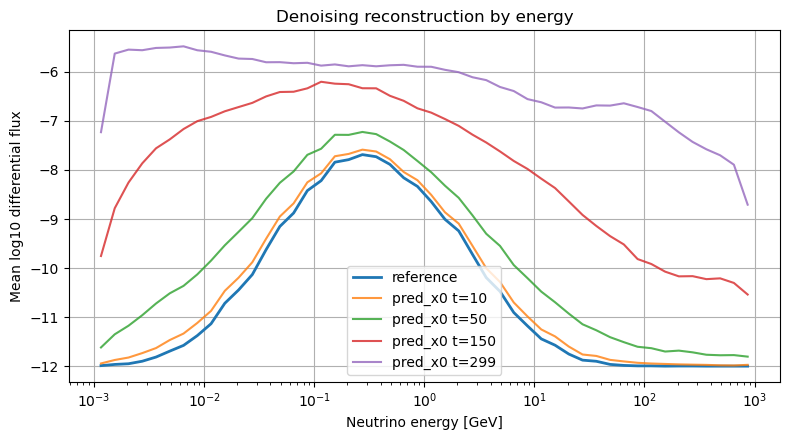

In [35]:
# Section 11.3 diagnostic: denoising reconstruction from partially noised validation cubes.
required_section10_objects = ["generated", "reference_cubes", "sample_condition_batch", "model_for_sampling"]
missing_section10_objects = [name for name in required_section10_objects if name not in globals()]
if missing_section10_objects:
    raise RuntimeError(f"Run Section 10 result visualization first. Missing objects: {missing_section10_objects}")

DENOISING_TEST_TIMESTEPS = [10, 50, 150, CONFIG.diffusion_steps - 1]
DENOISING_TEST_BATCH_SIZE = min(CONFIG.sample_count, CONFIG.batch_size)

denoise_batch = next(iter(val_loader))
x0 = denoise_batch["x"][:DENOISING_TEST_BATCH_SIZE].to(DEVICE).float()
condition = denoise_batch["condition"][:DENOISING_TEST_BATCH_SIZE].to(DEVICE).float()
valid_mask = denoise_batch["valid_mask"][:DENOISING_TEST_BATCH_SIZE].to(DEVICE)
reference_denorm = dataset.denormalize(x0)

model.eval()
denoising_rows = []
reconstructions = []
with torch.no_grad():
    for t_value in DENOISING_TEST_TIMESTEPS:
        t_value = int(np.clip(t_value, 0, diffusion.steps - 1))
        t = torch.full((x0.shape[0],), t_value, device=DEVICE, dtype=torch.long)
        noise = torch.randn_like(x0)
        xt = diffusion.q_sample(x0, t, noise)
        pred = model(xt, t, condition)
        pred_x0, _ = diffusion.predict_x0_and_noise(xt, t, pred)
        reconstructions.append((t_value, dataset.denormalize(pred_x0)))
        metrics_t = projection_rmse(pred_x0, x0, valid_mask)
        metrics_t["timestep"] = t_value
        metrics_t["normalized_mse"] = float(torch.mean((pred_x0 - x0).pow(2)).detach().cpu())
        denoising_rows.append(metrics_t)

denoising_table = pd.DataFrame(denoising_rows).sort_values("timestep")
display(denoising_table)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(denoising_table["timestep"], denoising_table["normalized_mse"], marker="o")
axes[0].set_xlabel("Diffusion timestep")
axes[0].set_ylabel("Normalized x0 MSE")
axes[0].set_title("Denoising reconstruction error")
for col in ["energy_projection_rmse", "theta_projection_rmse", "flavor_projection_rmse"]:
    axes[1].plot(denoising_table["timestep"], denoising_table[col], marker="o", label=col.replace("_projection_rmse", ""))
axes[1].set_xlabel("Diffusion timestep")
axes[1].set_ylabel("Projection RMSE")
axes[1].set_title("Projection preservation")
axes[1].legend()
plt.tight_layout()
plt.show()

sample_id = 0
ref_energy = reference_denorm[sample_id].mean(axis=(0, 1, 2))
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(dataset.energy_centers, ref_energy, label="reference", linewidth=2)
for t_value, recon in reconstructions:
    ax.plot(dataset.energy_centers, recon[sample_id].mean(axis=(0, 1, 2)), label=f"pred_x0 t={t_value}", alpha=0.8)
ax.set_xscale("log")
ax.set_xlabel("Neutrino energy [GeV]")
ax.set_ylabel("Mean log10 differential flux")
ax.set_title("Denoising reconstruction by energy")
ax.legend()
plt.tight_layout()
plt.show()


### 11.4. DDPM Versus DDIM Sampling Test

This test generates the same number of samples using full DDPM sampling and accelerated DDIM sampling. DDIM with few steps is much faster, but it can amplify errors when the denoiser is not yet accurate.

**Expected result:**

DDPM with all diffusion steps should be at least as stable as DDIM. DDIM should preserve the same broad physical structure if the denoiser is well trained and the number of DDIM steps is sufficient.

**Possible problems:**

If DDPM looks substantially better than DDIM, increase `SAMPLE_STEPS` or use DDPM for evaluation. If both are poor, the problem is not just sampler acceleration; inspect training quality, support modeling, and dataset sparsity.

,sampler,seconds,min,max
0,ddpm,2.868156,-29.157291,8.394061
1,ddim_25,0.266275,-29.926144,8.188085
2,ddim_50,0.541997,-28.472950,7.653895
3,ddim_100,1.081843,-27.467556,7.937020


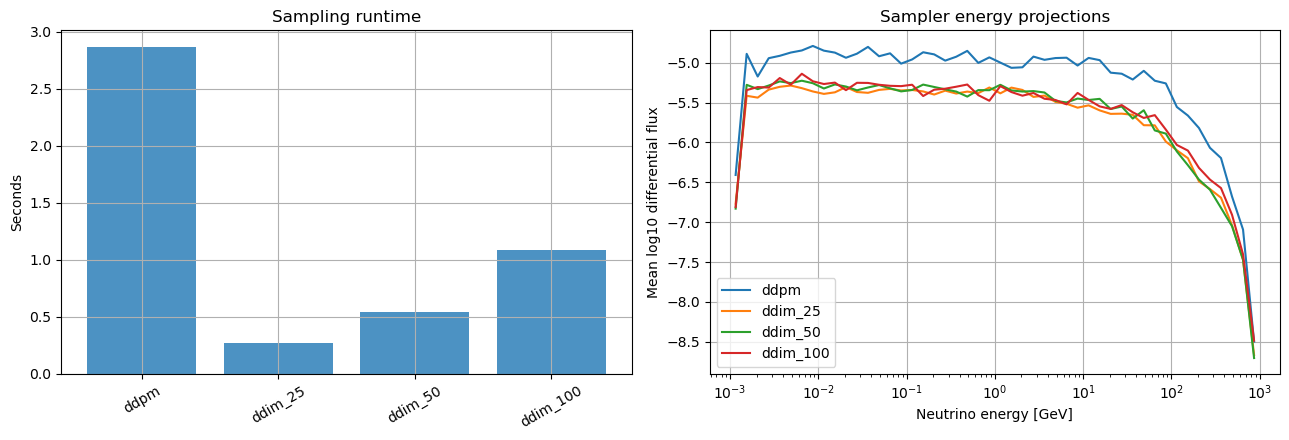

In [36]:
# Section 11.4 diagnostic: compare full DDPM and accelerated DDIM sampling.
required_section10_objects = ["generated", "reference_cubes", "sample_condition_batch", "model_for_sampling"]
missing_section10_objects = [name for name in required_section10_objects if name not in globals()]
if missing_section10_objects:
    raise RuntimeError(f"Run Section 10 result visualization first. Missing objects: {missing_section10_objects}")

RUN_DDPM_DDIM_COMPARISON = True
DDPM_DDIM_SAMPLE_COUNT = min(2, CONFIG.sample_count)
DDIM_COMPARISON_STEPS = [25, 50, 100]

if RUN_DDPM_DDIM_COMPARISON:
    comparison_condition = sample_condition_batch[:DDPM_DDIM_SAMPLE_COUNT].to(DEVICE).float()
    comparison_shape = (comparison_condition.shape[0], *dataset.sample_shape)
    sampler_outputs = {}
    sampler_times = []

    for method, steps in [("ddpm", None), *[("ddim", s) for s in DDIM_COMPARISON_STEPS]]:
        start_time = time.time()
        with torch.no_grad():
            sample_norm = diffusion.sample(model_for_sampling, comparison_shape, DEVICE, comparison_condition, method=method, sampling_steps=steps)
        elapsed = time.time() - start_time
        label = method if steps is None else f"{method}_{steps}"
        sampler_outputs[label] = dataset.denormalize(sample_norm)
        sampler_times.append({"sampler": label, "seconds": elapsed, "min": float(np.nanmin(sampler_outputs[label])), "max": float(np.nanmax(sampler_outputs[label]))})

    sampler_table = pd.DataFrame(sampler_times)
    display(sampler_table)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].bar(sampler_table["sampler"], sampler_table["seconds"], color="tab:blue", alpha=0.8)
    axes[0].tick_params(axis="x", rotation=30)
    axes[0].set_ylabel("Seconds")
    axes[0].set_title("Sampling runtime")
    for label, arr in sampler_outputs.items():
        axes[1].plot(dataset.energy_centers, arr[0].mean(axis=(0, 1, 2)), label=label)
    axes[1].set_xscale("log")
    axes[1].set_xlabel("Neutrino energy [GeV]")
    axes[1].set_ylabel("Mean log10 differential flux")
    axes[1].set_title("Sampler energy projections")
    axes[1].legend()
    plt.tight_layout()
    plt.show()
else:
    print("DDPM/DDIM comparison disabled. Set RUN_DDPM_DDIM_COMPARISON = True to run it.")


### 11.5. Support Precision, Recall, and F1 Test

This test converts reference and generated cubes into occupied-bin masks using a threshold such as the first percentile of real valid flux or a physics-motivated floor. It then computes precision, recall, and F1 for generated support.

**Expected result:**

A useful model should place flux in the same sparse regions as the reference. Precision measures whether generated occupied bins are physically plausible; recall measures whether real occupied bins are recovered.

**Possible problems:**

Low precision means the model paints flux across empty regions. Low recall means it misses real flux regions. The current visual discrepancy suggests precision may be poor because the generated theta-energy map occupies much more area than the reference.

,threshold,tp,fp,fn,precision,recall,f1
0,-299.0,442368,0,0,1.000000,1.0,1.000000
1,-12.0,68366,308771,0,0.181276,1.0,0.306916
2,-12.0,68366,308771,0,0.181276,1.0,0.306916


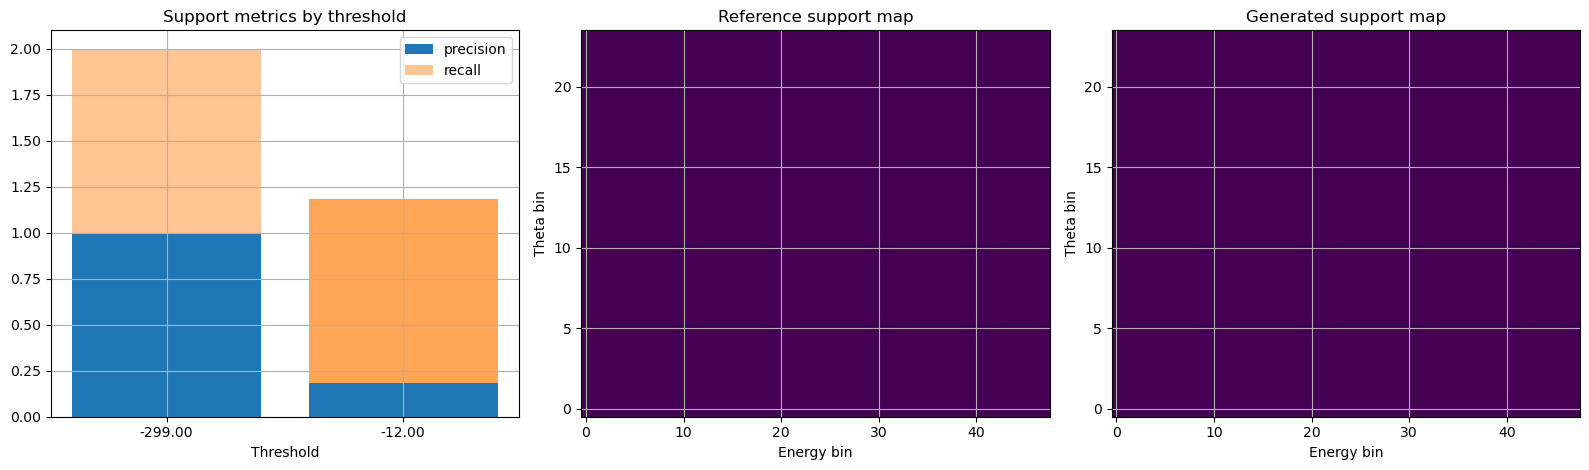

In [37]:
# Section 11.5 diagnostic: support precision, recall, and F1.
required_section10_objects = ["generated", "reference_cubes", "sample_condition_batch", "model_for_sampling"]
missing_section10_objects = [name for name in required_section10_objects if name not in globals()]
if missing_section10_objects:
    raise RuntimeError(f"Run Section 10 result visualization first. Missing objects: {missing_section10_objects}")

def support_metrics(real: np.ndarray, pred: np.ndarray, threshold: float) -> dict[str, float]:
    real_support = np.asarray(real) > threshold
    pred_support = np.asarray(pred) > threshold
    tp = int(np.logical_and(real_support, pred_support).sum())
    fp = int(np.logical_and(~real_support, pred_support).sum())
    fn = int(np.logical_and(real_support, ~pred_support).sum())
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    return {"threshold": threshold, "tp": tp, "fp": fp, "fn": fn, "precision": precision, "recall": recall, "f1": f1}

real_support_eval = np.asarray(reference_cubes, dtype=np.float32)
gen_support_eval = np.asarray(generated, dtype=np.float32)
valid_real_values = real_support_eval[real_support_eval > -299.0]
thresholds = [
    -299.0,
    float(np.nanpercentile(valid_real_values, 1)) if valid_real_values.size else -299.0,
    float(np.nanpercentile(valid_real_values, 10)) if valid_real_values.size else -299.0,
]
support_table = pd.DataFrame([support_metrics(real_support_eval, gen_support_eval, threshold) for threshold in thresholds])
display(support_table)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
axes[0].bar([f"{t:.2f}" for t in support_table["threshold"]], support_table["precision"], label="precision")
axes[0].bar([f"{t:.2f}" for t in support_table["threshold"]], support_table["recall"], bottom=support_table["precision"], alpha=0.45, label="recall")
axes[0].set_title("Support metrics by threshold")
axes[0].set_xlabel("Threshold")
axes[0].legend()

threshold = thresholds[0]
real_support_map = (real_support_eval[0, 0] > threshold).mean(axis=0)
gen_support_map = (gen_support_eval[0, 0] > threshold).mean(axis=0)
axes[1].imshow(real_support_map, origin="lower", aspect="auto")
axes[1].set_title("Reference support map")
axes[1].set_xlabel("Energy bin")
axes[1].set_ylabel("Theta bin")
axes[2].imshow(gen_support_map, origin="lower", aspect="auto")
axes[2].set_title("Generated support map")
axes[2].set_xlabel("Energy bin")
axes[2].set_ylabel("Theta bin")
plt.tight_layout()
plt.show()


### 11.6. Masked and Projection-Level Error Test

This test reports errors separately on valid bins, invalid bins, and collapsed physical projections by flavor, energy, theta, and height. It should be computed both in normalized training space and after denormalizing back to `log10_differential_flux`.

**Expected result:**

Errors on valid bins and physical projections should decrease together. Generated projections should reproduce the reference energy peak and flavor ordering, not only minimize average tensor MSE.

**Possible problems:**

If global MSE is low but projection errors are high, the model is optimizing the dominant empty background rather than the physically important sparse support. This points toward stronger support-aware losses, separate occupancy modeling, coarser bins, or better sample construction in the dataset notebook.

,region,rmse,mae,fraction
0,all_bins,7.043548,5.773214,1.0
1,reference_valid,7.043548,5.773214,1.0
2,reference_invalid,NaN,NaN,0.0


,projection,rmse,mae
0,flavor,5.761047,4.936739
1,height,4.887861,4.873772
2,theta,4.926029,4.873772
3,energy,5.072710,4.873774


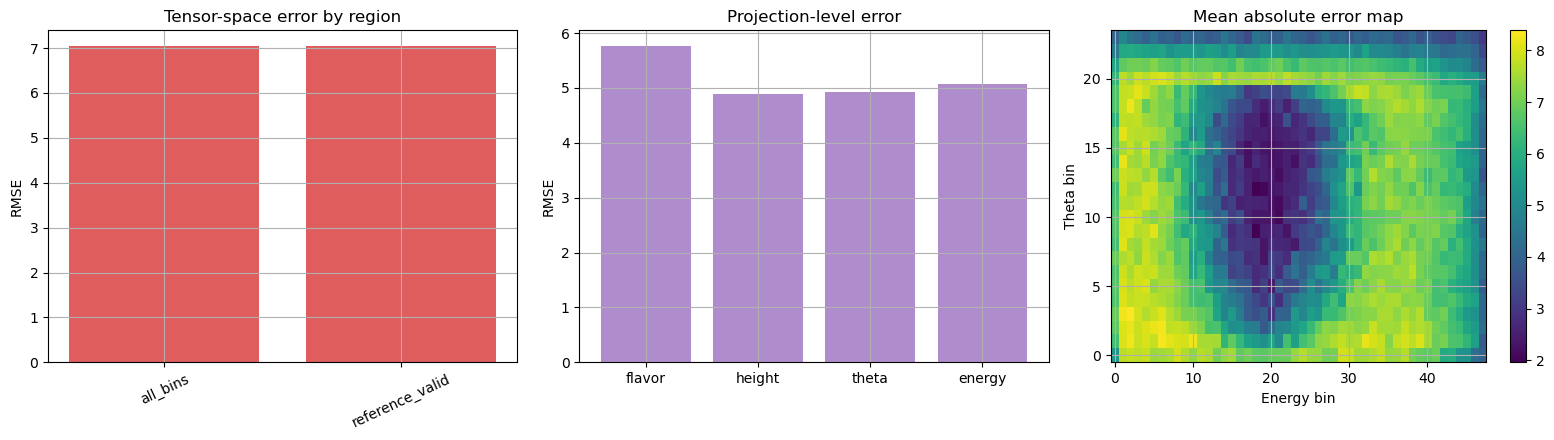

In [38]:
# Section 11.6 diagnostic: masked, invalid-background, and projection-level errors.
required_section10_objects = ["generated", "reference_cubes", "sample_condition_batch", "model_for_sampling"]
missing_section10_objects = [name for name in required_section10_objects if name not in globals()]
if missing_section10_objects:
    raise RuntimeError(f"Run Section 10 result visualization first. Missing objects: {missing_section10_objects}")

real_eval = np.asarray(reference_cubes, dtype=np.float32)
gen_eval = np.asarray(generated, dtype=np.float32)
assert real_eval.shape == gen_eval.shape

valid_threshold = -299.0
valid_region = real_eval > valid_threshold
invalid_region = ~valid_region

def region_rmse(a: np.ndarray, b: np.ndarray, region: np.ndarray) -> float:
    if not np.any(region):
        return float("nan")
    return float(np.sqrt(np.mean(np.square(a[region] - b[region]))))

error_rows = [
    {"region": "all_bins", "rmse": float(np.sqrt(np.mean(np.square(real_eval - gen_eval)))), "mae": float(np.mean(np.abs(real_eval - gen_eval))), "fraction": 1.0},
    {"region": "reference_valid", "rmse": region_rmse(real_eval, gen_eval, valid_region), "mae": float(np.mean(np.abs(real_eval[valid_region] - gen_eval[valid_region]))) if np.any(valid_region) else np.nan, "fraction": float(valid_region.mean())},
    {"region": "reference_invalid", "rmse": region_rmse(real_eval, gen_eval, invalid_region), "mae": float(np.mean(np.abs(real_eval[invalid_region] - gen_eval[invalid_region]))) if np.any(invalid_region) else np.nan, "fraction": float(invalid_region.mean())},
]
error_table = pd.DataFrame(error_rows)
display(error_table)

projection_rows = []
projection_axes = {
    "flavor": (0, 2, 3, 4),
    "height": (0, 1, 3, 4),
    "theta": (0, 1, 2, 4),
    "energy": (0, 1, 2, 3),
}
for name, axes_to_mean in projection_axes.items():
    real_proj = real_eval.mean(axis=axes_to_mean)
    gen_proj = gen_eval.mean(axis=axes_to_mean)
    projection_rows.append({"projection": name, "rmse": rmse(real_proj, gen_proj), "mae": float(np.mean(np.abs(real_proj - gen_proj)))})
projection_error_table = pd.DataFrame(projection_rows)
display(projection_error_table)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].bar(error_table["region"], error_table["rmse"], color="tab:red", alpha=0.75)
axes[0].tick_params(axis="x", rotation=25)
axes[0].set_ylabel("RMSE")
axes[0].set_title("Tensor-space error by region")
axes[1].bar(projection_error_table["projection"], projection_error_table["rmse"], color="tab:purple", alpha=0.75)
axes[1].set_ylabel("RMSE")
axes[1].set_title("Projection-level error")
error_map = np.mean(np.abs(real_eval[0] - gen_eval[0]), axis=0).mean(axis=0)
im = axes[2].imshow(error_map, origin="lower", aspect="auto")
axes[2].set_title("Mean absolute error map")
axes[2].set_xlabel("Energy bin")
axes[2].set_ylabel("Theta bin")
fig.colorbar(im, ax=axes[2])
plt.tight_layout()
plt.show()


## 12. Hyperparameter and Optimization Experiments

This section shows a practical optimization workflow. Start with short, cheap experiments that vary one or two knobs at a time, compare validation loss and baseline ratio, then promote the best configuration to a longer training run in Section 8.

Recommended process:

1. Run a tiny overfit test on 1-4 cubes to verify the model can learn.
2. Sweep learning rate on short runs; this usually has the highest leverage.
3. Sweep batch size if VRAM allows it; larger batches can stabilize gradients but may need a learning-rate change.
4. Compare model capacity with `base_channels` and `time_dim`.
5. Compare diffusion schedule settings such as `diffusion_steps`, `beta_start`, and `beta_end`.
6. Compare optimization techniques such as valid-mask loss, gradient clipping, weight decay, AMP, and EMA decay.
7. Choose the best short-run configuration by validation loss and physical metrics, then retrain longer.


In [39]:
# Section 12: short experiment grid. Keep epochs low first; promote only the best run.
EXPERIMENT_EPOCHS = 20
RUN_EXPERIMENTS = True  # Set True when you want to launch the sweep.

experiment_grid = [
    {"experiment_name": "lr_1e-4", "learning_rate": 1e-4, "batch_size": CONFIG.batch_size, "base_channels": CONFIG.base_channels, "use_valid_mask_loss": True},
    {"experiment_name": "lr_2e-4_default", "learning_rate": 2e-4, "batch_size": CONFIG.batch_size, "base_channels": CONFIG.base_channels, "use_valid_mask_loss": True},
    {"experiment_name": "lr_5e-4", "learning_rate": 5e-4, "batch_size": CONFIG.batch_size, "base_channels": CONFIG.base_channels, "use_valid_mask_loss": True},
    {"experiment_name": "batch_4", "learning_rate": CONFIG.learning_rate, "batch_size": 4, "base_channels": CONFIG.base_channels, "use_valid_mask_loss": True},
    {"experiment_name": "smaller_unet", "learning_rate": CONFIG.learning_rate, "batch_size": CONFIG.batch_size, "base_channels": max(8, CONFIG.base_channels // 2), "use_valid_mask_loss": True},
    {"experiment_name": "no_valid_mask_loss", "learning_rate": CONFIG.learning_rate, "batch_size": CONFIG.batch_size, "base_channels": CONFIG.base_channels, "use_valid_mask_loss": False},
]
display(pd.DataFrame(experiment_grid))

experiment_results: list[dict[str, Any]] = []
if RUN_EXPERIMENTS:
    for exp in experiment_grid:
        result = train_diffusion_model(
            epochs=EXPERIMENT_EPOCHS,
            weight_decay=CONFIG.weight_decay,
            grad_clip_norm=CONFIG.grad_clip_norm,
            diffusion_steps=CONFIG.diffusion_steps,
            beta_start=CONFIG.beta_start,
            beta_end=CONFIG.beta_end,
            beta_schedule=CONFIG.beta_schedule,
            prediction_target=CONFIG.prediction_target,
            min_snr_gamma=CONFIG.min_snr_gamma,
            time_dim=CONFIG.time_dim,
            condition_dim=CONFIG.condition_dim,
            ema_decay=CONFIG.ema_decay,
            use_amp=CONFIG.use_amp,
            min_valid_loss_weight=CONFIG.min_valid_loss_weight,
            scheduler_patience=CONFIG.scheduler_patience,
            scheduler_factor=CONFIG.scheduler_factor,
            seed=CONFIG.seed,
            save_checkpoints=False,
            verbose=True,
            **exp,
        )
        torch.manual_seed(123)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(123)
        baseline = baseline_zero_noise_loss(
            result["val_loader"],
            result["diffusion"],
            use_valid_mask_loss=result["config"]["use_valid_mask_loss"],
            min_valid_loss_weight=result["config"]["min_valid_loss_weight"],
        )
        val_loss = run_epoch(
            result["model"],
            result["val_loader"],
            result["diffusion"],
            optimizer=None,
            scaler=None,
            ema=None,
            use_valid_mask_loss=result["config"]["use_valid_mask_loss"],
            min_valid_loss_weight=result["config"]["min_valid_loss_weight"],
            amp_enabled=result["config"]["use_amp"] and AMP_DEVICE_TYPE == "cuda",
        )["loss"]
        experiment_results.append({
            **result["config"],
            "best_val_loss": result["best_val"],
            "best_epoch": result["best_epoch"],
            "final_train_loss": result["final_train_loss"],
            "final_val_loss": result["final_val_loss"],
            "baseline_ratio": val_loss / baseline,
            "parameter_count": result["parameter_count"],
        })

    experiments_table = pd.DataFrame(experiment_results).sort_values("best_val_loss")
    display(experiments_table)
    experiments_path = CONFIG.generated_dir / "optimization_experiments.csv"
    experiments_table.to_csv(experiments_path, index=False)
    print(f"Saved experiment comparison: {experiments_path}")
else:
    print("Set RUN_EXPERIMENTS = True to launch the optimization sweep.")
    


,experiment_name,learning_rate,batch_size,base_channels,use_valid_mask_loss
0,lr_1e-4,0.0001,4,32,True
1,lr_2e-4_default,0.0002,4,32,True
2,lr_5e-4,0.0005,4,32,True
3,batch_4,0.0002,4,32,True
4,smaller_unet,0.0002,4,16,True
5,no_valid_mask_loss,0.0002,4,32,False


[lr_1e-4] epoch=001 | train_loss=1.593544 | val_loss=1.151673 | support=1.0032 | val_energy_rmse=0.0464 | lr=1.00e-04 | t=1.4 s.
[lr_1e-4] epoch=002 | train_loss=1.104766 | val_loss=0.942438 | support=0.8443 | val_energy_rmse=0.0844 | lr=1.00e-04 | t=1.4 s.
[lr_1e-4] epoch=003 | train_loss=0.985801 | val_loss=0.935273 | support=0.7264 | val_energy_rmse=0.0319 | lr=1.00e-04 | t=1.5 s.
[lr_1e-4] epoch=004 | train_loss=0.869581 | val_loss=0.780032 | support=0.6057 | val_energy_rmse=0.0210 | lr=1.00e-04 | t=1.4 s.
[lr_1e-4] epoch=005 | train_loss=0.736307 | val_loss=0.668552 | support=0.5538 | val_energy_rmse=0.0544 | lr=1.00e-04 | t=1.4 s.
[lr_1e-4] epoch=006 | train_loss=0.782756 | val_loss=0.795956 | support=0.5287 | val_energy_rmse=0.0275 | lr=1.00e-04 | t=1.4 s.
[lr_1e-4] epoch=007 | train_loss=0.783380 | val_loss=0.714700 | support=0.4836 | val_energy_rmse=0.0346 | lr=1.00e-04 | t=1.4 s.
[lr_1e-4] epoch=008 | train_loss=0.757946 | val_loss=0.830190 | support=0.4572 | val_energy_rmse=

,experiment_name,epochs,learning_rate,batch_size,weight_decay,grad_clip_norm,diffusion_steps,beta_start,beta_end,beta_schedule,...,support_pos_weight,scheduler_patience,scheduler_factor,seed,best_val_loss,best_epoch,final_train_loss,final_val_loss,baseline_ratio,parameter_count
3,batch_4,20,0.0002,4,0.0001,1.0,300,0.0001,0.02,cosine,...,None,6,0.8,42,0.222722,17,0.375279,0.435385,0.131404,2308524
5,no_valid_mask_loss,20,0.0002,4,0.0001,1.0,300,0.0001,0.02,cosine,...,None,6,0.8,42,0.231932,17,0.384108,0.443934,0.132577,2308524
1,lr_2e-4_default,20,0.0002,4,0.0001,1.0,300,0.0001,0.02,cosine,...,None,6,0.8,42,0.236226,17,0.377769,0.467171,0.138574,2308524
2,lr_5e-4,20,0.0005,4,0.0001,1.0,300,0.0001,0.02,cosine,...,None,6,0.8,42,0.274837,17,0.399940,0.467848,0.138986,2308524
0,lr_1e-4,20,0.0001,4,0.0001,1.0,300,0.0001,0.02,cosine,...,None,6,0.8,42,0.298201,17,0.461985,0.554044,0.178991,2308524
4,smaller_unet,20,0.0002,4,0.0001,1.0,300,0.0001,0.02,cosine,...,None,6,0.8,42,0.344447,17,0.521061,0.615159,0.200956,705052


Saved experiment comparison: V:\output\data\difussion\model\run_2\generated\optimization_experiments.csv


## 13. Single-Parameter Sweep Analysis

This section performs a one-dimensional sweep over a single hyperparameter while keeping the rest of the training configuration fixed. It is useful after the broader experiment grid in Section 12, because it lets you inspect how sensitive the model is to one parameter and identify a stable operating range rather than a single lucky value.

The default example sweeps `learning_rate` over 20 logarithmically spaced values between `1e-6` and `1e-1`. Each run calls the same `train_diffusion_model` function used in Sections 8 and 12, stores comparable metrics, prints a comparison table, and plots both training and validation loss as a function of the swept parameter.

Set `RUN_SINGLE_PARAMETER_SWEEP = True` when you want to launch the sweep. Start with a small `SWEEP_EPOCHS` value, then rerun a narrower interval around the best region with more epochs.


In [40]:
print("\n" + "=" * 80)
print(f"{'PARAMETER':<35} {'VALUE'}")
print("=" * 80)

for field in fields(CONFIG):
    value = getattr(CONFIG, field.name)
    print(f"{field.name:<35} {value}")

print("=" * 80)


PARAMETER                           VALUE
dataset_path                        V:\output\data\difussion\dataset\run_2\dataset_neutrino_cubes.h5
checkpoint_dir                      V:\output\data\difussion\model\run_2\checkpoints
generated_dir                       V:\output\data\difussion\model\run_2\generated
model_file                          V:\output\data\difussion\model\run_2\model_difussion_neutrino_cube3D.h5
model_last_epoch                    V:\output\data\difussion\model\run_2\checkpoints\model_last_epoch.pt
model_best_epoch                    V:\output\data\difussion\model\run_2\checkpoints\model_best_epoch.pt
cube_target                         log10_differential_flux_valid
use_valid_mask_loss                 True
min_valid_loss_weight               0.0
loss_weight_source                  raw_counts
loss_weight_epsilon                 0.001
loss_weight_clip                    10.0
seed                                42
train_fraction                      0.8
val_fraction  


Experiment 0/15: sweep_learning_rate_1.000e-04
**********************************************************************
[sweep_learning_rate_1.000e-04] epoch=001 | train_loss=1.593544 | val_loss=1.151673 | support=1.0032 | val_energy_rmse=0.0464 | lr=1.00e-04 | t=1.4 s.
[sweep_learning_rate_1.000e-04] epoch=002 | train_loss=1.104766 | val_loss=0.942438 | support=0.8443 | val_energy_rmse=0.0844 | lr=1.00e-04 | t=1.4 s.
[sweep_learning_rate_1.000e-04] epoch=003 | train_loss=0.985801 | val_loss=0.935273 | support=0.7264 | val_energy_rmse=0.0319 | lr=1.00e-04 | t=1.4 s.
[sweep_learning_rate_1.000e-04] epoch=004 | train_loss=0.869581 | val_loss=0.780033 | support=0.6057 | val_energy_rmse=0.0210 | lr=1.00e-04 | t=1.4 s.
[sweep_learning_rate_1.000e-04] epoch=005 | train_loss=0.736307 | val_loss=0.668553 | support=0.5538 | val_energy_rmse=0.0544 | lr=1.00e-04 | t=1.4 s.
[sweep_learning_rate_1.000e-04] epoch=006 | train_loss=0.782756 | val_loss=0.795957 | support=0.5287 | val_energy_rmse=0.0275 

,experiment_name,learning_rate,best_val_loss,best_epoch,final_train_loss,final_val_loss,baseline_ratio,parameter_count,epochs
9,sweep_learning_rate_4.394e-04,0.000439,0.133449,50,0.163337,0.133449,0.049738,2308524,50
10,sweep_learning_rate_5.179e-04,0.000518,0.135280,50,0.173420,0.135280,0.050703,2308524,50
8,sweep_learning_rate_3.728e-04,0.000373,0.141173,50,0.182408,0.141173,0.051688,2308524,50
7,sweep_learning_rate_3.162e-04,0.000316,0.149471,43,0.181006,0.150825,0.056501,2308524,50
6,sweep_learning_rate_2.683e-04,0.000268,0.165638,43,0.218862,0.176020,0.067099,2308524,50
5,sweep_learning_rate_2.276e-04,0.000228,0.171456,50,0.213793,0.171456,0.067390,2308524,50
4,sweep_learning_rate_1.931e-04,0.000193,0.200385,38,0.233545,0.212232,0.081843,2308524,50
3,sweep_learning_rate_1.638e-04,0.000164,0.210992,26,0.272715,0.229735,0.092453,2308524,50
11,sweep_learning_rate_6.105e-04,0.000611,0.218782,43,0.247249,0.242545,0.099508,2308524,50
2,sweep_learning_rate_1.389e-04,0.000139,0.224714,43,0.269734,0.245145,0.102744,2308524,50


Saved single-parameter sweep table: V:\output\data\difussion\model\run_2\generated\single_parameter_sweep_learning_rate.csv


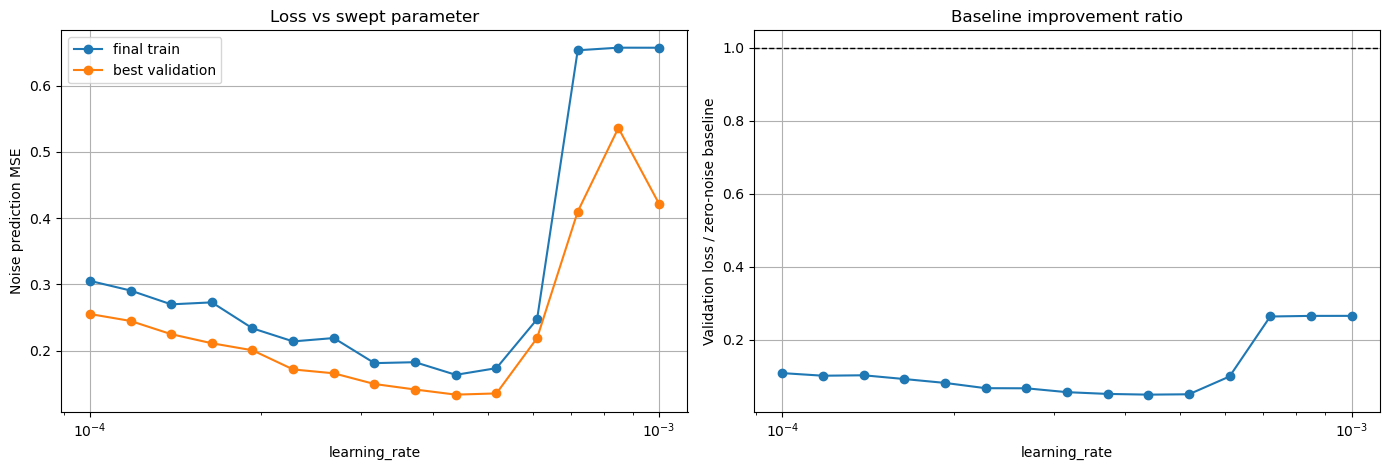

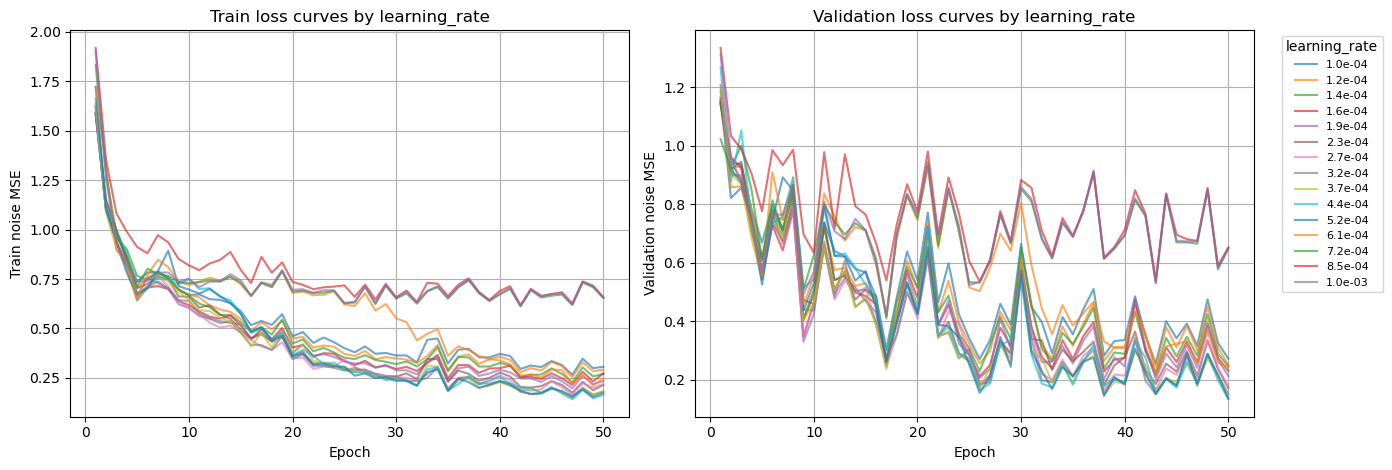

In [41]:
# Section 13: one-dimensional hyperparameter sweep.
RUN_SINGLE_PARAMETER_SWEEP = True  # Set True to launch the sweep.
SWEEP_PARAMETER_FLOAT = True
SWEEP_PARAMETER_INT = False
SWEEP_PARAMETER = "learning_rate"
SWEEP_VALUES = np.logspace(-4, -3, 15)
SWEEP_EPOCHS = 50
"""
SWEEP_PARAMETER = "batch_size"
SWEEP_VALUES = np.array([1, 2, 4, 8, 16, 32])

SWEEP_PARAMETER = "base_channels"
SWEEP_VALUES = np.array([8, 16, 32, 48, 64, 80, 96])

SWEEP_PARAMETER = "min_valid_loss_weight"
SWEEP_VALUES = np.array([0.001, 0.01, 0.03, 0.05, 0.07, 0.1])
"""
# Fixed settings for all runs in this sweep. Change these only when you want a new baseline context.
sweep_fixed_config = {
    "learning_rate": 5e-4,
    "batch_size": CONFIG.batch_size,
    "base_channels": CONFIG.base_channels,
    "time_dim": CONFIG.time_dim,
    "condition_dim": CONFIG.condition_dim,
    "weight_decay": CONFIG.weight_decay,
    "grad_clip_norm": CONFIG.grad_clip_norm,
    "diffusion_steps": CONFIG.diffusion_steps,
    "beta_start": CONFIG.beta_start,
    "beta_end": CONFIG.beta_end,
    "beta_schedule": CONFIG.beta_schedule,
    "prediction_target": CONFIG.prediction_target,
    "min_snr_gamma": CONFIG.min_snr_gamma,
    "ema_decay": CONFIG.ema_decay,
    "use_amp": CONFIG.use_amp,
    "use_valid_mask_loss": CONFIG.use_valid_mask_loss,
    "min_valid_loss_weight": CONFIG.min_valid_loss_weight,
    "scheduler_patience": CONFIG.scheduler_patience,
    "scheduler_factor": CONFIG.scheduler_factor,
    "seed": CONFIG.seed,
}

single_parameter_results: list[dict[str, Any]] = []
single_parameter_histories: dict[str, pd.DataFrame] = {}

if RUN_SINGLE_PARAMETER_SWEEP:
    for ix, value in enumerate(SWEEP_VALUES):
        if SWEEP_PARAMETER_FLOAT:
            value = float(value)
        if SWEEP_PARAMETER_INT:
            value = int(value)
        experiment_name = f"sweep_{SWEEP_PARAMETER}_{value:.3e}"
        print(f'\nExperiment {ix}/{len(SWEEP_VALUES)}: {experiment_name}')
        print('*'*70)
        run_kwargs = dict(sweep_fixed_config)
        run_kwargs[SWEEP_PARAMETER] = value

        result = train_diffusion_model(
            experiment_name=experiment_name,
            epochs=SWEEP_EPOCHS,
            save_checkpoints=False,
            verbose=True,
            **run_kwargs,
        )

        torch.manual_seed(123)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(123)
        baseline = baseline_zero_noise_loss(
            result["val_loader"],
            result["diffusion"],
            use_valid_mask_loss=result["config"]["use_valid_mask_loss"],
            min_valid_loss_weight=result["config"]["min_valid_loss_weight"],
        )
        val_loss = run_epoch(
            result["model"],
            result["val_loader"],
            result["diffusion"],
            optimizer=None,
            scaler=None,
            ema=None,
            use_valid_mask_loss=result["config"]["use_valid_mask_loss"],
            min_valid_loss_weight=result["config"]["min_valid_loss_weight"],
            amp_enabled=result["config"]["use_amp"] and AMP_DEVICE_TYPE == "cuda",
        )["loss"]

        history = result["history"].copy()
        history[SWEEP_PARAMETER] = value
        single_parameter_histories[experiment_name] = history
        single_parameter_results.append(
            {
                "experiment_name": experiment_name,
                SWEEP_PARAMETER: value,
                "best_val_loss": result["best_val"],
                "best_epoch": result["best_epoch"],
                "final_train_loss": result["final_train_loss"],
                "final_val_loss": result["final_val_loss"],
                "baseline_ratio": val_loss / baseline,
                "parameter_count": result["parameter_count"],
                "epochs": SWEEP_EPOCHS,
            }
        )

    single_parameter_table = pd.DataFrame(single_parameter_results).sort_values(SWEEP_PARAMETER)
    display(single_parameter_table.sort_values("best_val_loss"))

    sweep_path = CONFIG.generated_dir / f"single_parameter_sweep_{SWEEP_PARAMETER}.csv"
    single_parameter_table.to_csv(sweep_path, index=False)
    print(f"Saved single-parameter sweep table: {sweep_path}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
    axes[0].plot(single_parameter_table[SWEEP_PARAMETER], single_parameter_table["final_train_loss"], marker="o", label="final train")
    axes[0].plot(single_parameter_table[SWEEP_PARAMETER], single_parameter_table["best_val_loss"], marker="o", label="best validation")
    axes[0].set_xscale("log")
    axes[0].set_xlabel(SWEEP_PARAMETER)
    axes[0].set_ylabel("Noise prediction MSE")
    axes[0].set_title("Loss vs swept parameter")
    axes[0].legend()

    axes[1].plot(single_parameter_table[SWEEP_PARAMETER], single_parameter_table["baseline_ratio"], marker="o")
    axes[1].axhline(1.0, color="black", linestyle="--", linewidth=1)
    axes[1].set_xscale("log")
    axes[1].set_xlabel(SWEEP_PARAMETER)
    axes[1].set_ylabel("Validation loss / zero-noise baseline")
    axes[1].set_title("Baseline improvement ratio")
    plt.tight_layout()
    plt.show()

    histories_long = pd.concat(single_parameter_histories.values(), ignore_index=True)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
    for value, group in histories_long.groupby(SWEEP_PARAMETER):
        label = f"{value:.1e}"
        axes[0].plot(group["epoch"], group["train_loss"], alpha=0.65, label=label)
        axes[1].plot(group["epoch"], group["val_loss"], alpha=0.65, label=label)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Train noise MSE")
    axes[0].set_title(f"Train loss curves by {SWEEP_PARAMETER}")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Validation noise MSE")
    axes[1].set_title(f"Validation loss curves by {SWEEP_PARAMETER}")
    axes[1].legend(title=SWEEP_PARAMETER, bbox_to_anchor=(1.04, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    preview_table = pd.DataFrame({SWEEP_PARAMETER: SWEEP_VALUES})
    print("Set RUN_SINGLE_PARAMETER_SWEEP = True to launch the single-parameter sweep.")
    print(f"Parameter: {SWEEP_PARAMETER}")
    print(f"Values: {len(SWEEP_VALUES)} logarithmic points from {SWEEP_VALUES.min():.1e} to {SWEEP_VALUES.max():.1e}")
    display(preview_table)
